##Kudzu vine model

01 - Patch construction

02 - Grid Search

**03 - PSO**

04 - Simulation

05 - Map

ref: https://pyswarms.readthedocs.io/en/latest/intro.html

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
 !pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)

In [ ]:
patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_patch_attributes_V5.csv")

D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_D_ij_shortest_V5.npy")

In [ ]:
patch_df.head()

,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop,A_i
0,0,100000000.0,100000000.0,1.0,0,0,2.531998e+06,9.663946e+07,0.0,0.0,828540.11590,0.025320,0.966395,0.0,0.0,0.008285,100.0
1,1,100000000.0,100000000.0,1.0,0,0,0.000000e+00,1.000000e+08,0.0,0.0,0.00000,0.000000,1.000000,0.0,0.0,0.000000,100.0
2,2,100000000.0,100000000.0,1.0,0,0,1.298706e+06,9.870129e+07,0.0,0.0,0.00000,0.012987,0.987013,0.0,0.0,0.000000,100.0
3,3,100000000.0,100000000.0,1.0,0,0,5.383980e+06,9.403906e+07,0.0,0.0,576963.47265,0.053840,0.940391,0.0,0.0,0.005770,100.0
4,4,100000000.0,100000000.0,1.0,0,0,3.931651e+06,9.606835e+07,0.0,0.0,0.00000,0.039317,0.960683,0.0,0.0,0.000000,100.0


In [ ]:
patch_df.columns

Index(['patch_id', 'cell_area', 'land_area', 'land_prop', 'occyear1',
       'occyear2', 'Agriculture_area', 'Forest_area', 'Freshwater_area',
       'Marine_area', 'Urban_area', 'Agriculture_prop', 'Forest_prop',
       'Freshwater_prop', 'Marine_prop', 'Urban_prop', 'A_i'],
      dtype='object')

In [ ]:
O_j = patch_df["occyear1"].to_numpy(dtype=float)
obsyear2 = patch_df["occyear2"].to_numpy(dtype=float)

A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

Agriculture_prop = patch_df["Agriculture_prop"].to_numpy(dtype=float)
Forest_prop = patch_df["Forest_prop"].to_numpy(dtype=float)
Freshwater_prop = patch_df["Freshwater_prop"].to_numpy(dtype=float)
Marine_prop = patch_df["Marine_prop"].to_numpy(dtype=float)
Urban_prop = patch_df["Urban_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()

In [ ]:
print("n patches =", len(patch_id))
print("occupied year1 =", int(O_j.sum()))
print("occupied year2 =", int(obsyear2.sum()))

n patches = 1123
occupied year1 = 24
occupied year2 = 35


In [ ]:
### null model RMSE

rmse_null = np.sqrt(np.mean((obsyear2-0)**2))
print("Null model RMSE:", rmse_null)

Null model RMSE: 0.17654041535771625




---


# PSO

$$
\begin{aligned}
\alpha_i &= \alpha \\
y_i &= \sum_{k=1}^{5} p_{ik}y_k \\
e_i &= \sum_{k=1}^{5} p_{ik}e_k \\
x_i &= \sum_{k=1}^{5} p_{ik}x_k
\end{aligned}
$$

$$
k \in \{1,2,3,4,5\}
=
\{\mathrm{urban},\mathrm{agriculture},\mathrm{forest},\mathrm{freshwater},\mathrm{marine}\}
$$

$$
\begin{aligned}
& S_i(\mathrm{year1})
=
\sum_{j\neq i}
\exp(-\alpha_i d_{ij})
p_j(\mathrm{year1})A_j
\\[8pt]
& C_i(\mathrm{year1})
=
\frac{\left[S_i(\mathrm{year1})\right]^2}
{\left[S_i(\mathrm{year1})\right]^2+y_i^2}
\\[8pt]
& E_i(\mathrm{year1})
=
\min\left[
\frac{e_i}{A_i^{x_i}},
\,1
\right]
\\[8pt]
& p_i(\mathrm{year2})
=
\frac{C_i(\mathrm{year1})}
{C_i(\mathrm{year1})
+\left[1-C_i(\mathrm{year1})\right]E_i(\mathrm{year1})}
\end{aligned}
$$

    alpha_global

    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,

    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,

    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine


In [ ]:
## Define IFM function

def run_ifm_rmse(alpha_global,

                 y_Forest,
                 y_Agriculture,
                 y_Urban,
                 y_Freshwater,
                 y_Marine,

                 e_Forest,
                 e_Agriculture,
                 e_Urban,
                 e_Freshwater,
                 e_Marine,

                 x_Forest,
                 x_Agriculture,
                 x_Urban,
                 x_Freshwater,
                 x_Marine):

    y_i = (
        Forest_prop * y_Forest
        + Agriculture_prop * y_Agriculture
        + Urban_prop * y_Urban
        + Freshwater_prop * y_Freshwater
        + Marine_prop * y_Marine
    )

    e_i = (
        Forest_prop * e_Forest
        + Agriculture_prop * e_Agriculture
        + Urban_prop * e_Urban
        + Freshwater_prop * e_Freshwater
        + Marine_prop * e_Marine
    )

    x_i = (
        Forest_prop * x_Forest
        + Agriculture_prop * x_Agriculture
        + Urban_prop * x_Urban
        + Freshwater_prop * x_Freshwater
        + Marine_prop * x_Marine
    )

    # Connectivity kernel
    K_ij = np.exp(-alpha_global * D_ij)
    np.fill_diagonal(K_ij, 0.0)

    # Year 1
    S_i_year1 = K_ij @ (O_j * A_j)

    C_i_year1 = S_i_year1 ** 2 / (S_i_year1 ** 2 + y_i ** 2)

    E_i_year1 = np.minimum(e_i / (A_j ** x_i), 1.0)

    # Prediction for year 2
    p_i_year2 = C_i_year1 / (
        C_i_year1 + (1 - C_i_year1) * E_i_year1
    )

    # RMSE
    rmse = np.sqrt(np.mean((p_i_year2 - obsyear2) ** 2))

    return rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1

In [ ]:
def objective(params):

    costs = []

    for (
        alpha_global,

                 y_Forest,
                 y_Agriculture,
                 y_Urban,
                 y_Freshwater,
                 y_Marine,

                 e_Forest,
                 e_Agriculture,
                 e_Urban,
                 e_Freshwater,
                 e_Marine,

                 x_Forest,
                 x_Agriculture,
                 x_Urban,
                 x_Freshwater,
                 x_Marine
    ) in params:

        rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1= run_ifm_rmse(alpha_global,

                 y_Forest,
                 y_Agriculture,
                 y_Urban,
                 y_Freshwater,
                 y_Marine,

                 e_Forest,
                 e_Agriculture,
                 e_Urban,
                 e_Freshwater,
                 e_Marine,

                 x_Forest,
                 x_Agriculture,
                 x_Urban,
                 x_Freshwater,
                 x_Marine
        )

        n_pred_year2 = (p_i_year2 > 0.5).sum()

        penalty = 0.0
        # penalty = 0.001 * abs(n_pred_year2 - 794)

        costs.append(rmse + penalty)

    return np.array(costs)

# -------------PSO-----------------

## Round 1

In [ ]:
lower_bounds = np.array([0.1,
                         0.1,    0.1,   0.1,   0.1,    0.1,
                         0.001,  0.001, 0.001, 0.001,  0.001,
                         0.1,    0.1,   0.1,   0.1,    0.1,])
upper_bounds = np.array([2,
                         100, 100, 100,  100, 100,
                         1,   1,   1,   1,    1,
                         15, 15,  15,  15,  15])

bounds = (lower_bounds, upper_bounds)

In [ ]:
%%time

options = {
    "c1": 0.7,     # cognitive parameter
    "c2": 1.5,     # social parameter
    "w": 0.5       # inertia weight
}

optimizer = ps.single.GlobalBestPSO(
    n_particles=800,    ###
    dimensions=16,
    options=options,
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(
    objective,
    iters=50
)

print("best RMSE:", best_cost)
print("best params:", best_pos)

2026-08-13 20:00:19,775 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-13 20:24:29,670 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1604326795363106, best pos: [ 0.47227739 46.35077158 22.82137701 55.19282116 22.44430047 52.47188932
  0.73836678  0.44702925  0.08024307  0.64910029  0.91164528  0.54833914
  0.40967502  2.12879764  6.20585721  0.31817247]


best RMSE: 0.1604326795363106
best params: [ 0.47227739 46.35077158 22.82137701 55.19282116 22.44430047 52.47188932
  0.73836678  0.44702925  0.08024307  0.64910029  0.91164528  0.54833914
  0.40967502  2.12879764  6.20585721  0.31817247]
CPU times: user 36min 22s, sys: 3min 35s, total: 39min 57s
Wall time: 24min 9s


lower_bounds = np.array([0.1,
                         0.1,    0.1,   0.1,   0.1,    0.1,
                         0.001,  0.001, 0.001, 0.001,  0.001,
                         0.1,    0.1,   0.1,   0.1,    0.1,])

upper_bounds = np.array([1,
                         100, 100, 100,  100, 100,
                         0.5, 0.5, 0.5,  0.5,  0.5,
                         10, 10, 10, 10,  10])


bounds = (lower_bounds, upper_bounds)


best RMSE: 0.16206117276161655

best params: [ 0.80726808

39.22214186 57.48710261 27.71629663 57.89850274 65.78308491

0.30237432  0.38722759  0.35932417  0.28687874  0.26834343  1.86735937

2.32375562  3.20486453  8.12229307  2.21051097]

In [ ]:
# alpha_global,
# y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
# e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
# x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine

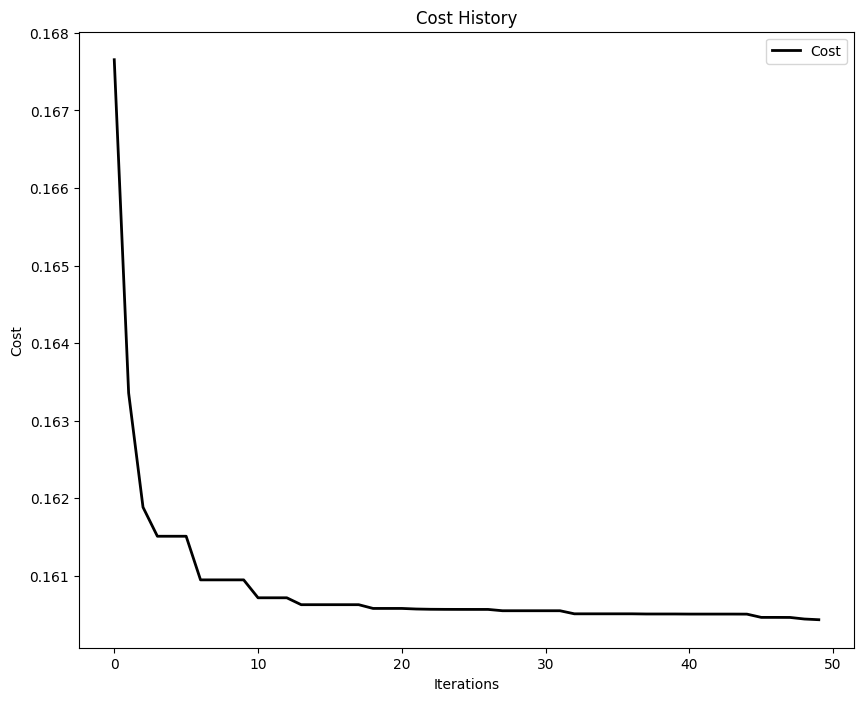

In [ ]:
plot_cost_history(cost_history=optimizer.cost_history)
plt.show()


## Round 2

In [ ]:
# the same counds
lower_bounds = np.array([0.1,
                         0.1,    0.1,   0.1,   0.1,    0.1,
                         0.001,  0.001, 0.001, 0.001,  0.001,
                         0.1,    0.1,   0.1,   0.1,    0.1,])
upper_bounds = np.array([2,
                         100, 100, 100,  100, 100,
                         1,   1,   1,   1,    1,
                         15, 15,  15,  15,  15])

bounds = (lower_bounds, upper_bounds)

In [ ]:
%%time

options = {
    "c1": 0.6,     # cognitive parameter
    "c2": 0.3,     # social parameter
    "w": 0.5       # inertia weight
}

optimizer = ps.single.GlobalBestPSO(
    n_particles=500,    ###
    dimensions=16,
    options=options,
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(
    objective,
    iters=50
)

print("best RMSE:", best_cost)
print("best params:", best_pos)

2026-08-13 18:38:49,384 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.6, 'c2': 0.3, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.162
2026-08-13 18:48:13,404 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16167452899157495, best pos: [ 0.83130678 70.15880699 56.2194184  38.14737306 41.16152084 62.22979273
  0.65666484  0.59336301  0.77958095  0.42753866  0.68200667  1.47658038
  2.29053523  4.20621327  9.17284984  1.98155684]


best RMSE: 0.16167452899157495
best params: [ 0.83130678 70.15880699 56.2194184  38.14737306 41.16152084 62.22979273
  0.65666484  0.59336301  0.77958095  0.42753866  0.68200667  1.47658038
  2.29053523  4.20621327  9.17284984  1.98155684]
CPU times: user 13min 53s, sys: 1min 33s, total: 15min 27s
Wall time: 9min 24s


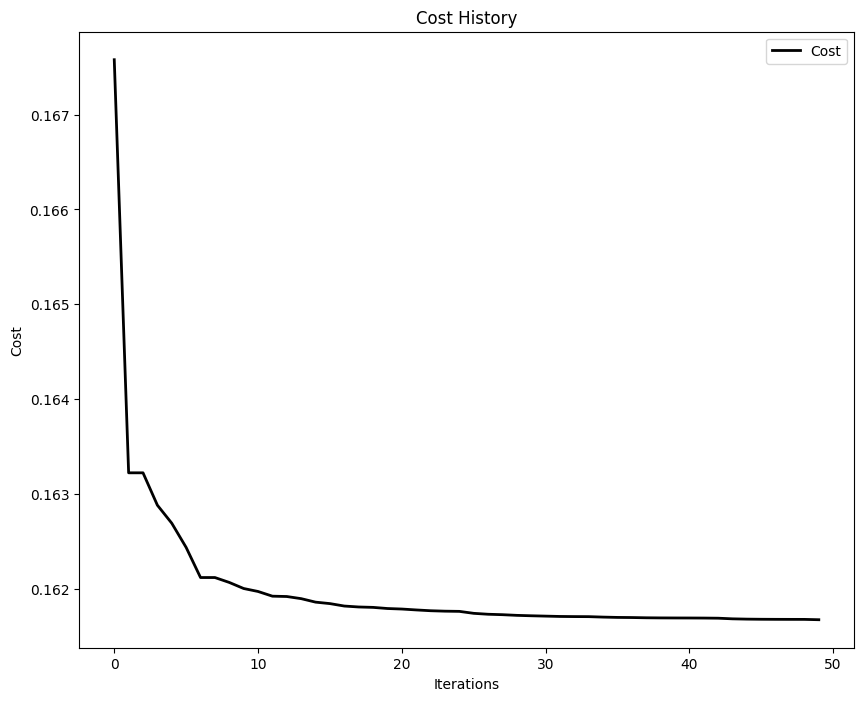

In [ ]:
plot_cost_history(cost_history=optimizer.cost_history)
plt.show()

## Round 3

In [ ]:
lower_bounds = np.array([
    0.8,
    50, 20, 30, 55, 15,
    0.2, 0.5, 0.5, 0.4, 0.7,
    2, 2, 2, 6, 1.5
])

upper_bounds = np.array([
    1.0,
    90, 50, 70, 100, 45,
    0.6, 0.9, 0.9, 0.8, 1.0,
    5, 5, 6, 10, 4
])

bounds = (lower_bounds, upper_bounds)

In [ ]:
%%time

options = {
    "c1": 0.6,     # cognitive parameter
    "c2": 0.3,     # social parameter
    "w": 0.5       # inertia weight
}

optimizer = ps.single.GlobalBestPSO(
    n_particles=500,    ###
    dimensions=16,
    options=options,
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(
    objective,
    iters=50
)

print("best RMSE:", best_cost)
print("best params:", best_pos)

2026-08-13 18:48:13,625 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.6, 'c2': 0.3, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.162
2026-08-13 19:03:32,167 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1620011907826879, best pos: [ 0.97311341 59.54717601 42.57043287 55.69697534 63.41063409 26.83258867
  0.48647195  0.84655725  0.7029118   0.4690626   0.89378325  2.00029403
  2.91891659  4.85494062  9.94951082  2.30221534]


best RMSE: 0.1620011907826879
best params: [ 0.97311341 59.54717601 42.57043287 55.69697534 63.41063409 26.83258867
  0.48647195  0.84655725  0.7029118   0.4690626   0.89378325  2.00029403
  2.91891659  4.85494062  9.94951082  2.30221534]
CPU times: user 22min 54s, sys: 2min 25s, total: 25min 20s
Wall time: 15min 18s


best RMSE: 0.1620011907826879

best params: [ 0.97311341

59.54717601 42.57043287 55.69697534 63.41063409 26.83258867

  0.48647195  0.84655725  0.7029118   0.4690626   0.89378325  

  2.00029403  2.91891659  4.85494062  9.94951082  2.30221534]



#---------------------------------------------------------------


#----------------- Using different seed-------------------------

# More social

In [ ]:
lower_bounds = np.array([0.1,
                         0.1,    0.1,   0.1,   0.1,    0.1,
                         0.001,  0.001, 0.001, 0.001,  0.001,
                         0.1,    0.1,   0.1,   0.1,    0.1,])
upper_bounds = np.array([1,
                         80, 80, 80,  80, 80,
                         1,   1,   1,   1, 1,
                         20, 20, 20, 20, 20])

bounds = (lower_bounds, upper_bounds)

In [ ]:
%%time

options = {
    "c1": 0.7,     # cognitive parameter
    "c2": 1.5,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=500,
        dimensions=16,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",
            "alpha_global",

            "y_Forest",
            "y_Agriculture",
            "y_Urban",
            "y_Freshwater",
            "y_Marine",

            "e_Forest",
            "e_Agriculture",
            "e_Urban",
            "e_Freshwater",
            "e_Marine",

            "x_Forest",
            "x_Agriculture",
            "x_Urban",
            "x_Freshwater",
            "x_Marine"
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


2026-08-14 21:00:57,265 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-14 21:16:31,059 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16004571239787085, best pos: [ 0.89478524 51.49799434 60.57727908 25.65047093  3.9371944  35.14024464
  0.80140633  0.55800931  0.45050736  0.30720452  0.56782869  0.16066727
  1.54604177  5.20817506 16.91677428  1.07077287]
2026-08-14 21:16:31,088 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 42
Best RMSE: 0.16004571239787085
Best params: [ 0.89478524 51.49799434 60.57727908 25.65047093  3.9371944  35.14024464
  0.80140633  0.55800931  0.45050736  0.30720452  0.56782869  0.16066727
  1.54604177  5.20817506 16.91677428  1.07077287]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.161
2026-08-14 21:31:49,673 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16064695704975018, best pos: [ 0.89136382 50.95578133 39.6776833  37.51056817 58.16980813 37.12666814
  0.53838833  0.6679537   0.55940158  0.39764425  0.39470691  0.62234289
  2.04302266  4.55196105 16.14613272  1.32478288]
2026-08-14 21:31:49,698 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 137
Best RMSE: 0.16064695704975018
Best params: [ 0.89136382 50.95578133 39.6776833  37.51056817 58.16980813 37.12666814
  0.53838833  0.6679537   0.55940158  0.39764425  0.39470691  0.62234289
  2.04302266  4.55196105 16.14613272  1.32478288]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.161
2026-08-14 21:47:09,501 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1605260587302663, best pos: [8.73922302e-01 6.60671378e+01 4.20296534e+01 4.00044596e+01
 4.85538447e+01 1.67780407e+01 6.20535459e-01 2.52159884e-01
 5.47706524e-02 4.35902362e-01 3.86879504e-01 7.26201291e-01
 1.22529825e+00 4.72622734e+00 1.54063035e+01 5.46784901e-01]
2026-08-14 21:47:09,529 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


...


Seed 890
Best RMSE: 0.16073285046804053
Best params: [ 0.88800433 45.18819976 54.65185859 63.09896985 45.93752263 36.991701
  0.25639084  0.16896764  0.76814905  0.4661082   0.32451827  0.39772993
  1.06515903  5.84061356 15.27059355  1.74981807]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.161
2026-08-14 23:18:50,322 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16085788587183814, best pos: [ 0.90590805 44.85745448 30.35318204 37.01517709 61.59354813 46.06484936
  0.40019008  0.80514265  0.31658508  0.49334983  0.63312489  0.43081311
  1.80255543  5.11069278 14.36155477  1.62423033]
2026-08-14 23:18:50,349 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 1024
Best RMSE: 0.16085788587183814
Best params: [ 0.90590805 44.85745448 30.35318204 37.01517709 61.59354813 46.06484936
  0.40019008  0.80514265  0.31658508  0.49334983  0.63312489  0.43081311
  1.80255543  5.11069278 14.36155477  1.62423033]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.162
2026-08-14 23:34:02,035 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16162666849888693, best pos: [ 0.79185272 13.72256836 23.54259371 50.49147211 15.37643481 13.59199439
  0.67120354  0.47637367  0.3558385   0.39778324  0.76499373  1.11786972
  1.99660009  3.37066072  9.189729    0.95789458]



Seed 2048
Best RMSE: 0.16162666849888693
Best params: [ 0.79185272 13.72256836 23.54259371 50.49147211 15.37643481 13.59199439
  0.67120354  0.47637367  0.3558385   0.39778324  0.76499373  1.11786972
  1.99660009  3.37066072  9.189729    0.95789458]
CPU times: user 3h 49min 39s, sys: 22min 29s, total: 4h 12min 8s
Wall time: 2h 33min 4s


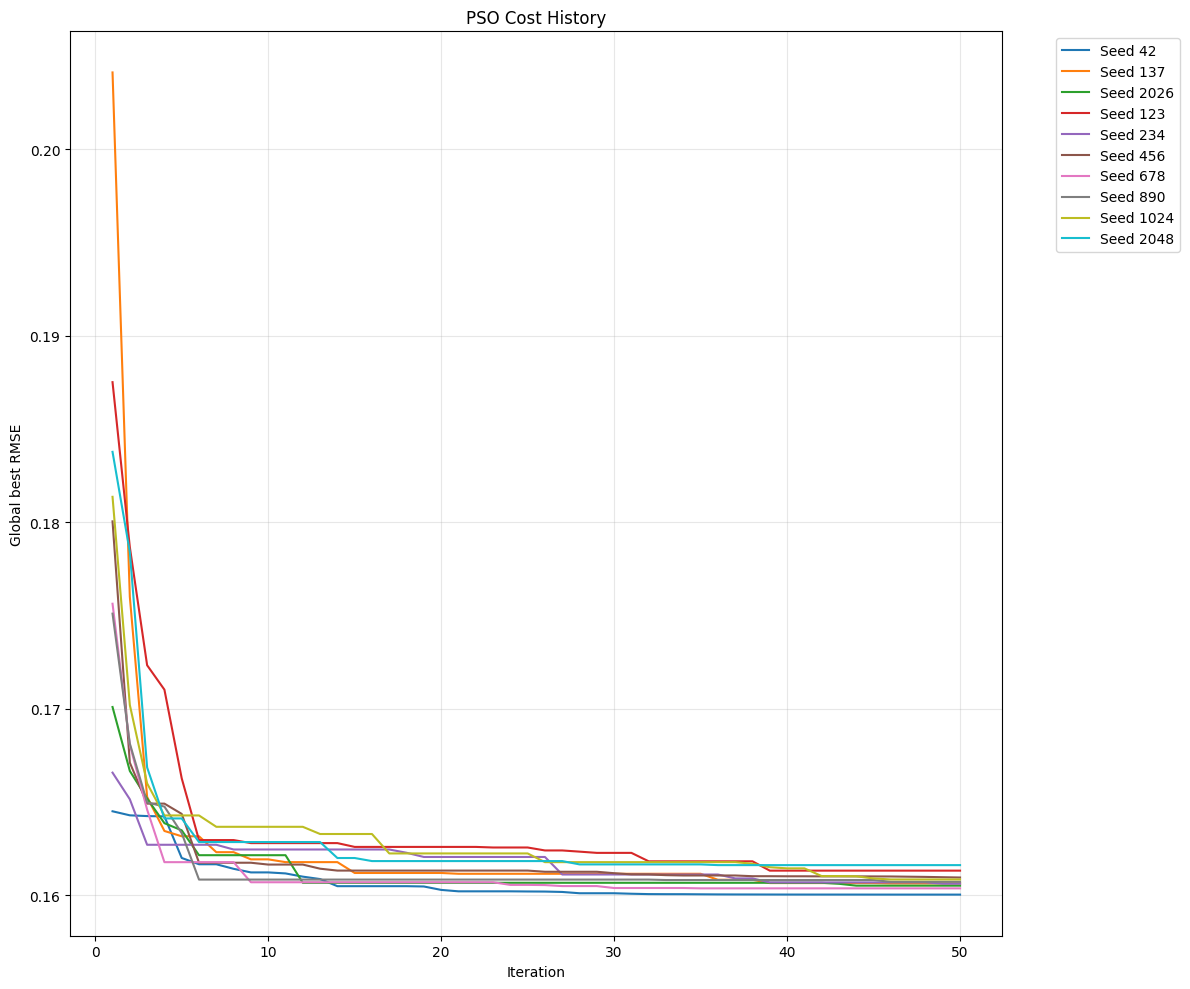

In [ ]:
plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### more social -- Round 2

In [ ]:
lower_bounds = np.array([0.5,
                         10,   10,  10,  1,  10,
                         0.01,  0.01, 0.01, 0.01,  0.01,
                         0.1,    0.5,   1,   5,    0.1,])
upper_bounds = np.array([1,
                         80, 80, 80,  80, 80,
                         1,   1,   1,   1, 1,
                         5,  10,  10, 20, 10])

bounds = (lower_bounds, upper_bounds)

In [ ]:
## more social  round 2
%%time

lower_bounds = np.array([0.5,
                         10,   10,  10,  1,  10,
                         0.01,  0.01, 0.01, 0.01,  0.01,
                         0.1,    0.5,   1,   5,    0.1,])
upper_bounds = np.array([1,
                         80, 80, 80,  80, 80,
                         1,   1,   1,   1, 1,
                         5,  10,  10, 20, 10])

bounds = (lower_bounds, upper_bounds)



seed_pos = np.array([
    0.89478524,
    51.49799434, 60.57727908, 25.65047093, 3.9371944, 35.14024464,
    0.80140633, 0.55800931, 0.45050736, 0.30720452, 0.56782869,
    0.16066727, 1.54604177, 5.20817506, 16.91677428, 1.07077287
])


options = {
    "c1": 0.7,
    "c2": 1.5,
    "w": 0.5
}


n_particles = 400
dimensions = 16
n_iterations = 50


result_path = (
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_pso_more_social_round2.csv"
)

history_path = (
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_pso_more_social_round2_cost_history.csv"
)


results = []
history_results = []


seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]


for seed in seeds:

    # Reproducible initialization for this run
    np.random.seed(seed)

    # 400 particles randomly initialized within Round 2 bounds
    init_pos = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(n_particles, dimensions)
    )


    # Using previous best fitting parameters as initial position
    init_pos[0] = np.clip(
        seed_pos,
        lower_bounds,
        upper_bounds
    )


    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=init_pos
    )


    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iterations
    )


    results.append([
        seed,
        best_cost,
        *best_pos
    ])


    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_global",

            "y_Forest",
            "y_Agriculture",
            "y_Urban",
            "y_Freshwater",
            "y_Marine",

            "e_Forest",
            "e_Agriculture",
            "e_Urban",
            "e_Freshwater",
            "e_Marine",

            "x_Forest",
            "x_Agriculture",
            "x_Urban",
            "x_Freshwater",
            "x_Marine"
        ]
    )

    #  save result
    result_df.to_csv(
        result_path,
        index=False
    )


    # save cost history
    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])


    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )


    # Save after every completed seed
    history_df.to_csv(
        history_path,
        index=False
    )


    print(f"Seed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)
    print("Initial position shape:", init_pos.shape)
    print()

2026-08-15 14:17:54,590 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 14:29:42,790 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15998880049203437, best pos: [ 0.89430775 54.67616978 60.40347613 28.33725364  3.31440163 35.13546371
  0.86291925  0.55841463  0.46407485  0.31409819  0.56739606  0.13111821
  1.55097426  5.29001233 16.96090772  0.94065539]
2026-08-15 14:29:42,855 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 42
Best RMSE: 0.15998880049203437
Best params: [ 0.89430775 54.67616978 60.40347613 28.33725364  3.31440163 35.13546371
  0.86291925  0.55841463  0.46407485  0.31409819  0.56739606  0.13111821
  1.55097426  5.29001233 16.96090772  0.94065539]
Initial position shape: (400, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 14:41:27,264 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16000957333759272, best pos: [ 0.89614014 51.49337625 60.62009473 25.50380494  4.00586264 35.08757496
  0.80287113  0.5603255   0.45060338  0.30666968  0.56797954  0.11584421
  1.54674296  5.20749352 16.91981981  0.11091656]
2026-08-15 14:41:27,298 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 137
Best RMSE: 0.16000957333759272
Best params: [ 0.89614014 51.49337625 60.62009473 25.50380494  4.00586264 35.08757496
  0.80287113  0.5603255   0.45060338  0.30666968  0.56797954  0.11584421
  1.54674296  5.20749352 16.91981981  0.11091656]
Initial position shape: (400, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 14:53:35,129 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16004245229723502, best pos: [ 0.89409257 51.94404775 60.52661698 28.42849647 28.20990527 35.51289347
  0.78250572  0.55795998  0.44890265  0.30950484  0.56815181  0.10405125
  1.54397641  5.20328616 16.95739858  0.60014929]
2026-08-15 14:53:35,181 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


...

Seed 890
Best RMSE: 0.1600058777985696
Best params: [ 0.89088336 50.95727477 60.5019305  24.85332506 19.32596945 35.32443016
  0.8881945   0.51458549  0.45522558  0.29935061  0.56875217  0.10667244
  1.54955387  5.16051524 17.01563384  1.1795467 ]
Initial position shape: (400, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 16:05:48,052 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16001966508673984, best pos: [ 0.89839782 51.74639309 61.6824327  25.92940625  3.94165943 35.16736365
  0.79239888  0.53074551  0.42967391  0.40456115  0.5752941   0.11487491
  1.57434637  5.24874364 16.97685211  1.50187955]
2026-08-15 16:05:48,100 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 1024
Best RMSE: 0.16001966508673984
Best params: [ 0.89839782 51.74639309 61.6824327  25.92940625  3.94165943 35.16736365
  0.79239888  0.53074551  0.42967391  0.40456115  0.5752941   0.11487491
  1.57434637  5.24874364 16.97685211  1.50187955]
Initial position shape: (400, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 16:17:25,714 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15995563657407205, best pos: [ 0.92079902 51.79464159 70.26272178 34.65255105 63.52329364 41.17249377
  0.92499058  0.58513008  0.48472941  0.25031015  0.60504344  0.10432582
  1.69392276  5.54536755 18.08863888  0.54741073]


Seed 2048
Best RMSE: 0.15995563657407205
Best params: [ 0.92079902 51.79464159 70.26272178 34.65255105 63.52329364 41.17249377
  0.92499058  0.58513008  0.48472941  0.25031015  0.60504344  0.10432582
  1.69392276  5.54536755 18.08863888  0.54741073]
Initial position shape: (400, 16)

CPU times: user 3h 12s, sys: 18min 4s, total: 3h 18min 16s
Wall time: 1h 59min 31s


In [ ]:
history_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round2_cost_history.csv")

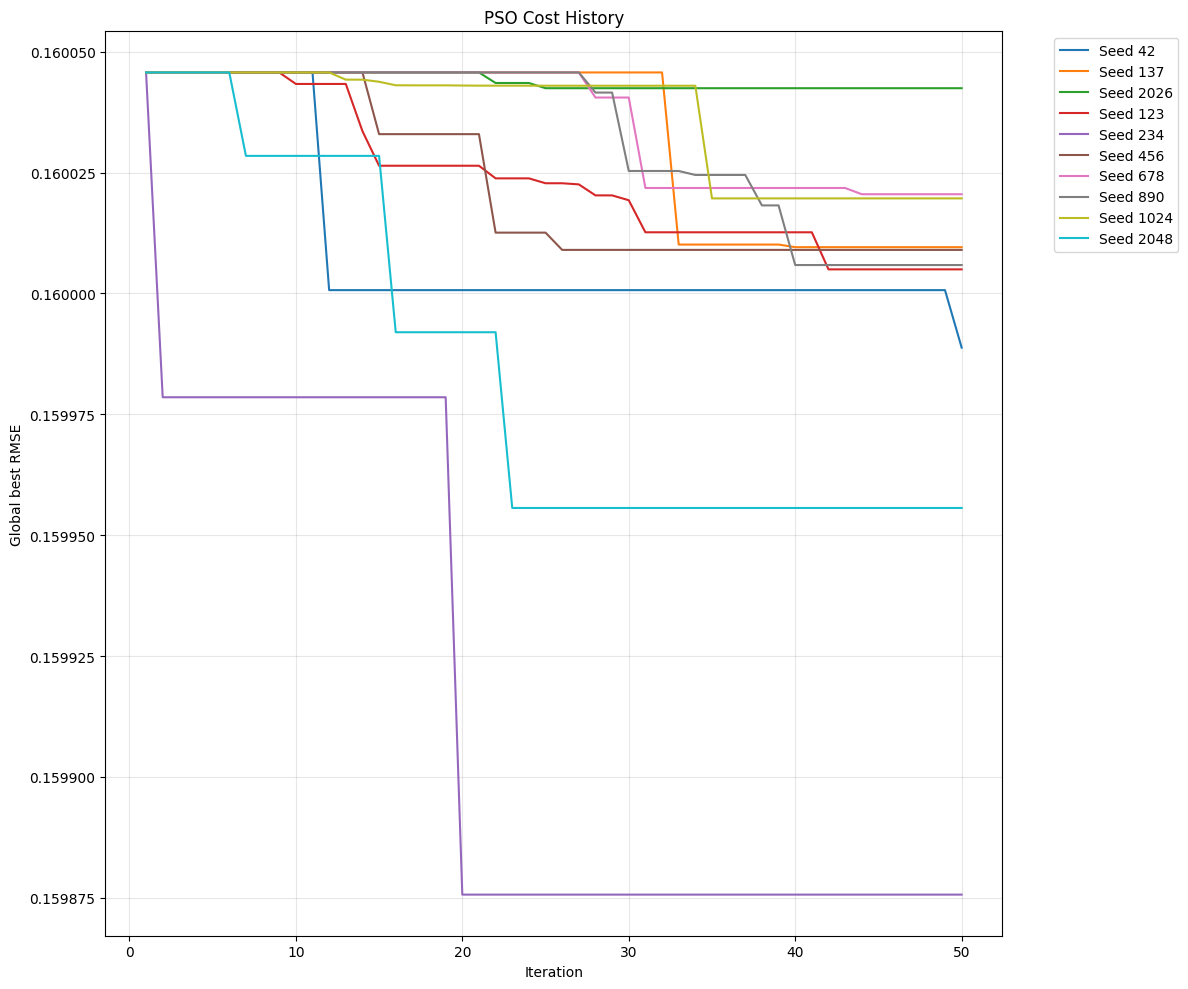

In [ ]:
plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



---



# More cognitive

In [ ]:
# alpha_global,
# y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
# e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
# x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine

In [ ]:
# options = {
#     "c1": 1.5
#     "c2": 0.7,
#     "w": 0.5
# }

In [ ]:
lower_bounds = np.array([0.1,
                         0.1,    0.1,   0.1,   0.1,    0.1,
                         0.001,  0.001, 0.001, 0.001,  0.001,
                         0.1,    0.1,   0.1,   0.1,    0.1,])
upper_bounds = np.array([1,
                         80, 80, 80,  80, 80,
                         1,  1,  1,  1,  1,
                         20, 20, 20, 20, 20])

bounds = (lower_bounds, upper_bounds)

In [ ]:
%%time

options = {
    "c1": 1.5,     # cognitive parameter
    "c2": 0.7,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=500,
        dimensions=16,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",
            "alpha_global",

            "y_Forest",
            "y_Agriculture",
            "y_Urban",
            "y_Freshwater",
            "y_Marine",

            "e_Forest",
            "e_Agriculture",
            "e_Urban",
            "e_Freshwater",
            "e_Marine",

            "x_Forest",
            "x_Agriculture",
            "x_Urban",
            "x_Freshwater",
            "x_Marine"
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


2026-08-15 00:04:18,936 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 00:17:16,991 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16021733258906215, best pos: [ 0.66066643 76.42439277 41.09901148 58.32721075 24.18839796 59.10857493
  0.71245855  0.55584624  0.63297318  0.41416529  0.82058358  0.10005246
  0.85213526  4.12264483 12.27170851  0.54337728]
2026-08-15 00:17:17,068 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 42
Best RMSE: 0.16021733258906215
Best params: [ 0.66066643 76.42439277 41.09901148 58.32721075 24.18839796 59.10857493
  0.71245855  0.55584624  0.63297318  0.41416529  0.82058358  0.10005246
  0.85213526  4.12264483 12.27170851  0.54337728]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 00:30:09,035 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1603968442113918, best pos: [ 0.59364899 58.80704558 42.59502938 47.59235488 59.22435787 40.47069758
  0.62391301  0.40085546  0.97252314  0.14874361  0.92680344  0.10043814
  0.87365019  3.45789549 10.49825137  0.39477216]
2026-08-15 00:30:09,106 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 137
Best RMSE: 0.1603968442113918
Best params: [ 0.59364899 58.80704558 42.59502938 47.59235488 59.22435787 40.47069758
  0.62391301  0.40085546  0.97252314  0.14874361  0.92680344  0.10043814
  0.87365019  3.45789549 10.49825137  0.39477216]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.161
2026-08-15 00:43:07,768 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1608181176732114, best pos: [ 0.82442113 49.75875204 26.403556   29.11177603 41.2501083  34.63609427
  0.33825766  0.56924168  0.79025656  0.64146381  0.54628814  0.57747023
  1.70539376  4.29739127 13.07386334  1.09240313]
2026-08-15 00:43:07,813 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


...


Seed 890
Best RMSE: 0.16126476259324243
Best params: [ 0.87683848 44.16173873 29.72452969 57.2320204  40.83589625 15.51805366
  0.65962064  0.68834592  0.57299812  0.58571116  0.41045449  0.86294119
  1.96463729  4.91551997 11.62717487  0.53917517]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 02:00:07,716 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1603217800629141, best pos: [ 0.93127094 75.14425079 56.05423541  7.15594292 74.25399772 30.60151834
  0.34156631  0.77744562  0.47153757  0.74884781  0.46884312  0.52875365
  2.0587949   4.92424452 17.17934003  0.40746293]
2026-08-15 02:00:07,750 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 1024
Best RMSE: 0.1603217800629141
Best params: [ 0.93127094 75.14425079 56.05423541  7.15594292 74.25399772 30.60151834
  0.34156631  0.77744562  0.47153757  0.74884781  0.46884312  0.52875365
  2.0587949   4.92424452 17.17934003  0.40746293]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.161
2026-08-15 02:13:07,042 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1606029047781002, best pos: [ 0.96036337 41.14178603 38.58460544 37.0318412  27.41060221 31.67568796
  0.51987844  0.42070388  0.47378515  0.56003927  0.80312101  0.59299377
  2.07322254  5.18805367 15.95802364  1.60548253]



Seed 2048
Best RMSE: 0.1606029047781002
Best params: [ 0.96036337 41.14178603 38.58460544 37.0318412  27.41060221 31.67568796
  0.51987844  0.42070388  0.47378515  0.56003927  0.80312101  0.59299377
  2.07322254  5.18805367 15.95802364  1.60548253]
CPU times: user 3h 30min 15s, sys: 19.3 s, total: 3h 30min 35s
Wall time: 2h 8min 48s


In [ ]:
history_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive_cost_history.csv")

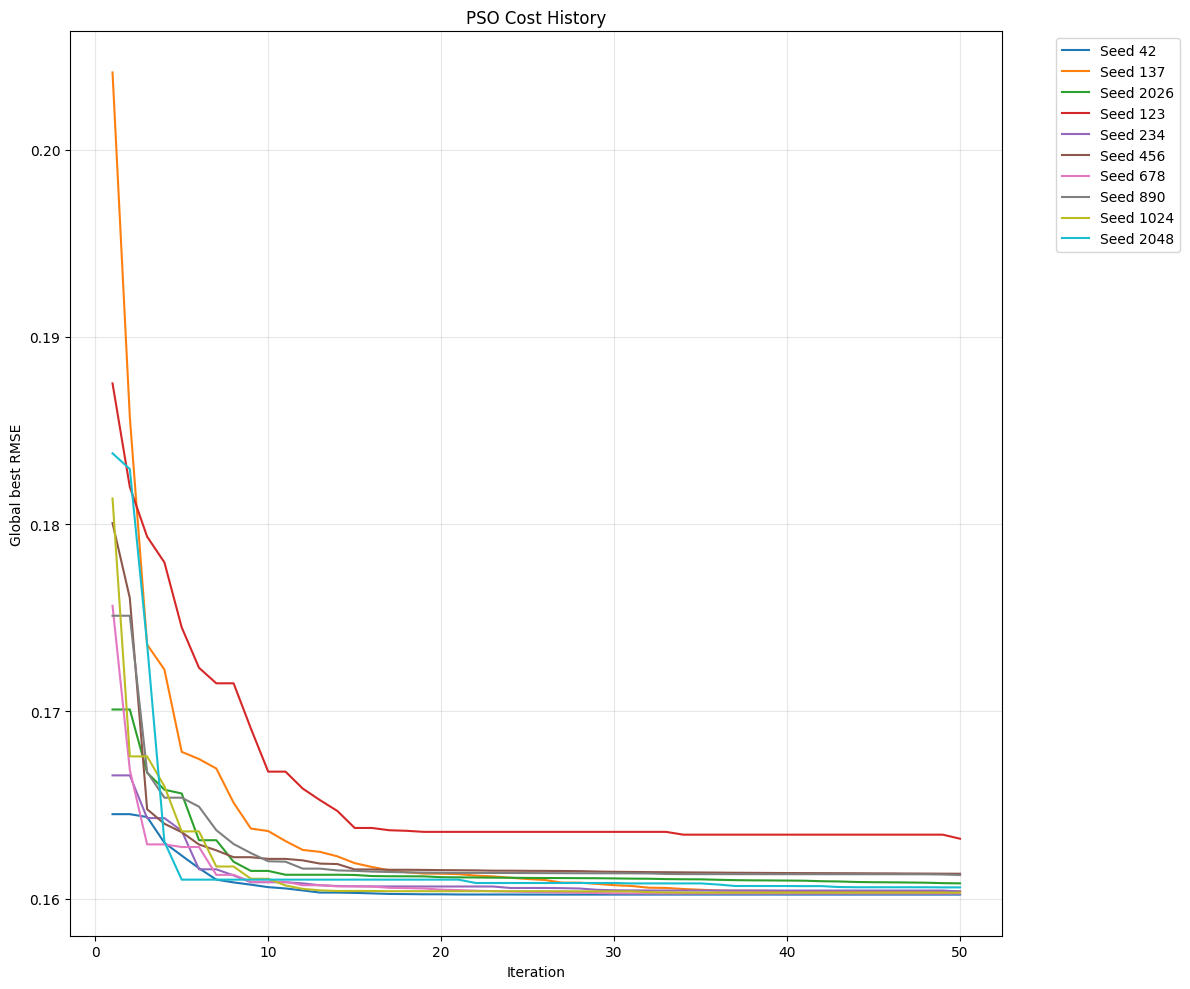

In [ ]:
seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
result_coginitive_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive.csv")

result_social_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social.csv")

In [ ]:
result_coginitive_df.describe()

,seed,best_rmse,param_1,param_2,param_3,param_4,param_5,param_6,param_7,param_8,param_9,param_10,param_11,param_12,param_13,param_14,param_15,param_16
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,1157.70000,0.160990,0.706048,44.263108,42.879616,34.148764,29.925755,50.861059,0.561420,0.593940,0.613403,0.391514,0.687111,0.609586,1.523565,3.552392,9.733346,1.007680
std,1243.97964,0.000578,0.152742,21.421145,17.064780,14.537273,20.443445,14.497542,0.194342,0.183246,0.168995,0.302864,0.160185,0.570553,0.811759,0.540498,0.485583,0.771858
min,42.00000,0.160291,0.485653,12.250149,17.040993,17.439818,0.578581,31.637394,0.165460,0.380694,0.316481,0.033384,0.428357,0.100063,0.286344,2.907804,8.382399,0.208637
25%,289.50000,0.160519,0.601411,29.849765,34.889653,24.290599,11.580171,39.469845,0.472612,0.463970,0.492540,0.155454,0.605344,0.101698,0.948917,3.185201,9.781351,0.370242
50%,784.00000,0.160888,0.667611,42.114901,41.473135,31.882693,38.212693,49.327691,0.552322,0.569761,0.650710,0.344534,0.694674,0.430818,1.353426,3.329576,9.889612,0.849898
75%,1775.50000,0.161498,0.808372,52.718738,48.531655,36.574291,43.674420,59.320301,0.692290,0.675245,0.733150,0.681732,0.753529,1.075108,2.137399,3.992833,9.965362,1.345108
max,4056.00000,0.161872,0.935604,78.219497,72.898463,61.792314,53.721321,75.273241,0.863062,0.978640,0.822423,0.820730,0.946410,1.560714,2.665405,4.481187,9.988719,2.411794


In [ ]:
result_social_df.describe()

,seed,best_rmse,param_1,param_2,param_3,param_4,param_5,param_6,param_7,param_8,param_9,param_10,param_11,param_12,param_13,param_14,param_15,param_16
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,765.800000,0.160764,0.749621,41.856802,51.594529,47.912232,30.148003,46.649116,0.699049,0.456461,0.610884,0.456062,0.526840,0.461559,1.417774,4.213990,11.709428,0.870941
std,747.826302,0.000299,0.092364,12.412756,12.851829,17.497476,18.650526,13.015400,0.160654,0.219566,0.233468,0.221061,0.128323,0.427306,0.582896,0.864559,2.309140,0.774422
min,42.000000,0.160341,0.632992,11.791202,23.158833,26.943616,0.109910,22.841628,0.516838,0.064226,0.306331,0.113379,0.328355,0.118424,0.543532,3.211711,6.712606,0.263032
25%,161.250000,0.160603,0.697565,39.744494,47.436627,30.279217,20.166294,40.237183,0.559092,0.343321,0.397596,0.299716,0.427504,0.181509,1.138147,3.564278,10.482446,0.341659
50%,567.000000,0.160693,0.724433,45.213348,53.351138,49.506931,30.441863,44.993816,0.652408,0.449323,0.608320,0.454382,0.555617,0.268842,1.413545,3.970808,12.251062,0.630202
75%,990.500000,0.161025,0.819045,48.673401,60.416244,60.923765,47.874449,52.737998,0.858839,0.645315,0.773998,0.642469,0.613517,0.754576,1.868045,4.790817,13.175289,0.897410
max,2048.000000,0.161241,0.909376,54.419762,68.488076,73.836469,49.935536,67.230851,0.930228,0.726545,0.987758,0.736761,0.693425,1.316915,2.260760,5.802280,14.380016,2.630049


### more cogginitive

In [ ]:
best_cognitive = result_coginitive_df.loc[
    result_coginitive_df["best_rmse"].idxmin()
]

best_social = result_social_df.loc[
    result_social_df["best_rmse"].idxmin()
]

print("Cognitive best RMSE:", best_cognitive["best_rmse"])
print("Social best RMSE:", best_social["best_rmse"])

Cognitive best RMSE: 0.1602905830716695
Social best RMSE: 0.1603406404162995


In [ ]:
alpha_global = best_cognitive["param_1"]

y_Forest = best_cognitive["param_2"]
y_Agriculture = best_cognitive["param_3"]
y_Urban = best_cognitive["param_4"]
y_Freshwater = best_cognitive["param_5"]
y_Marine = best_cognitive["param_6"]

e_Forest = best_cognitive["param_7"]
e_Agriculture = best_cognitive["param_8"]
e_Urban = best_cognitive["param_9"]
e_Freshwater = best_cognitive["param_10"]
e_Marine = best_cognitive["param_11"]

x_Forest = best_cognitive["param_12"]
x_Agriculture = best_cognitive["param_13"]
x_Urban = best_cognitive["param_14"]
x_Freshwater = best_cognitive["param_15"]
x_Marine = best_cognitive["param_16"]

In [ ]:
def run_ifm_rmse(alpha_global,

                 y_Forest,
                 y_Agriculture,
                 y_Urban,
                 y_Freshwater,
                 y_Marine,

                 e_Forest,
                 e_Agriculture,
                 e_Urban,
                 e_Freshwater,
                 e_Marine,

                 x_Forest,
                 x_Agriculture,
                 x_Urban,
                 x_Freshwater,
                 x_Marine):

    y_i = (
        Forest_prop * y_Forest
        + Agriculture_prop * y_Agriculture
        + Urban_prop * y_Urban
        + Freshwater_prop * y_Freshwater
        + Marine_prop * y_Marine
    )

    e_i = (
        Forest_prop * e_Forest
        + Agriculture_prop * e_Agriculture
        + Urban_prop * e_Urban
        + Freshwater_prop * e_Freshwater
        + Marine_prop * e_Marine
    )

    x_i = (
        Forest_prop * x_Forest
        + Agriculture_prop * x_Agriculture
        + Urban_prop * x_Urban
        + Freshwater_prop * x_Freshwater
        + Marine_prop * x_Marine
    )

    # Connectivity kernel
    K_ij = np.exp(-alpha_global * D_ij)
    np.fill_diagonal(K_ij, 0.0)

    # Year 1
    S_i_year1 = K_ij @ (O_j * A_j)

    C_i_year1 = S_i_year1 ** 2 / (S_i_year1 ** 2 + y_i ** 2)

    E_i_year1 = np.minimum(e_i / (A_j ** x_i), 1.0)

    # Prediction for year 2
    p_i_year2 = C_i_year1 / (
        C_i_year1 + (1 - C_i_year1) * E_i_year1
    )

    # RMSE
    rmse = np.sqrt(np.mean((p_i_year2 - obsyear2) ** 2))

    return rmse, p_i_year2, C_i_year1, E_i_year1, S_i_year1

In [ ]:
(
    rmse,
    p_i_year2,
    S_i_year1,
    C_i_year1,
    E_i_year1
) = run_ifm_rmse(
    alpha_global,
    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,
    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,
    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine
)

In [ ]:
print("RMSE:", rmse)
print("n_pred:", (p_i_year2 > 0.5).sum(), "\n")

print("Mean p_i_year2:", p_i_year2.mean())
print("Mean S_i_year1:", S_i_year1.mean())
print("Mean C_i_year1:", C_i_year1.mean())
print("Mean E_i_year1:", E_i_year1.mean())

RMSE: 0.16029058307166952
n_pred: 10 

Mean p_i_year2: 0.009765018505051064
Mean S_i_year1: 1.0461102555366087e-05
Mean C_i_year1: 0.10117181247276968
Mean E_i_year1: 0.03231717025144201




---

## More cognitive round 2


In [ ]:
lower_bounds = np.array([0.3,
                         20,   10,   10,   10,   10,
                         0.1,  0.1,  0.1, 0.05,  0.1,
                         0.05,  0.05,   1,   5, 0.1,])
upper_bounds = np.array([2,
                         80, 80, 80,  80, 80,
                         1.5,  1.5,  1.5,  1.5,  1.5,
                         5,  10, 10, 20, 10])

bounds = (lower_bounds, upper_bounds)


In [ ]:
%%time

seed_pos = np.array([
    0.66066643,
    76.42439277, 41.09901148, 58.32721075, 24.18839796, 59.10857493,
    0.71245855,  0.55584624,  0.63297318,  0.41416529,  0.82058358,
    0.10005246,  0.85213526,  4.12264483,  12.27170851, 0.54337728
])



options = {
    "c1": 1.5,     # cognitive parameter
    "c2": 0.7,     # social parameter
    "w": 0.5       # inertia weight
}



n_particles = 400
dimensions = 16
n_iterations = 50


result_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_pso_more_cognitive_round2.csv")

history_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_pso_more_cognitive_round2_cost_history.csv")


results = []
history_results = []


seeds = [42, 137, 2026, 123, 234,    456, 678, 890, 1024, 2048]


for seed in seeds:


    np.random.seed(seed)

    init_pos = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(n_particles, dimensions)
    )


    # Using previous best fitting parameters as initial position
    init_pos[0] = np.clip(
        seed_pos,
        lower_bounds,
        upper_bounds
    )


    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=init_pos
    )


    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iterations
    )


    # Save best result
    results.append([
        seed,
        best_cost,
        *best_pos
    ])


    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_global",

            "y_Forest",
            "y_Agriculture",
            "y_Urban",
            "y_Freshwater",
            "y_Marine",

            "e_Forest",
            "e_Agriculture",
            "e_Urban",
            "e_Freshwater",
            "e_Marine",

            "x_Forest",
            "x_Agriculture",
            "x_Urban",
            "x_Freshwater",
            "x_Marine"
        ]
    )


    # Save after every completed seed
    result_df.to_csv(
        result_path,
        index=False
    )


    # Save cost history
    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])


    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )


    # Save after every completed seed
    history_df.to_csv(
        history_path,
        index=False
    )


    print(f"Seed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)
    print("Initial position shape:", init_pos.shape)
    print()

2026-08-15 19:09:17,655 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 19:21:05,919 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16008401136237238, best pos: [ 0.67068259 77.11285386 39.73595698 57.62123595 24.07752217 57.61117726
  1.24996886  0.53028954  0.69250392  0.2039558   0.78125876  0.09229832
  1.02304995  4.12403428 13.14823153  0.54513026]
2026-08-15 19:21:05,962 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 42
Best RMSE: 0.16008401136237238
Best params: [ 0.67068259 77.11285386 39.73595698 57.62123595 24.07752217 57.61117726
  1.24996886  0.53028954  0.69250392  0.2039558   0.78125876  0.09229832
  1.02304995  4.12403428 13.14823153  0.54513026]
Initial position shape: (400, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 19:32:47,905 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16003269256829952, best pos: [7.30736041e-01 7.78417933e+01 3.91743835e+01 4.74222951e+01
 2.87203961e+01 5.85923621e+01 8.82553684e-01 8.54654229e-01
 8.71965373e-01 4.60740171e-01 8.21458718e-01 5.01688746e-02
 1.20009282e+00 4.45435079e+00 1.45059851e+01 1.20990002e+00]
2026-08-15 19:32:47,940 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 137
Best RMSE: 0.16003269256829952
Best params: [7.30736041e-01 7.78417933e+01 3.91743835e+01 4.74222951e+01
 2.87203961e+01 5.85923621e+01 8.82553684e-01 8.54654229e-01
 8.71965373e-01 4.60740171e-01 8.21458718e-01 5.01688746e-02
 1.20009282e+00 4.45435079e+00 1.45059851e+01 1.20990002e+00]
Initial position shape: (400, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 19:44:30,271 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16009731042510256, best pos: [6.61816816e-01 7.82674720e+01 4.01601235e+01 6.39026189e+01
 3.65530629e+01 6.02484819e+01 9.82193790e-01 4.79157565e-01
 5.92091443e-01 2.96338417e-01 7.83059446e-01 5.55589870e-02
 9.42286450e-01 4.06436226e+00 1.29522555e+01 5.03039399e-01]
2026-08-15 19:44:30,294 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


...

Seed 890
Best RMSE: 0.15976157651086534
Best params: [8.80280451e-01 7.71376346e+01 4.35939548e+01 6.24510575e+01
 2.03136166e+01 6.00296420e+01 1.24242178e+00 8.98008083e-01
 9.68765240e-01 4.20956876e-01 7.76099466e-01 5.00326206e-02
 1.61977164e+00 5.56315193e+00 1.82064491e+01 1.19008622e+00]
Initial position shape: (400, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 20:54:25,644 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16002574420518278, best pos: [7.42248351e-01 7.57488199e+01 4.88788088e+01 6.00071649e+01
 2.46755935e+01 6.38405871e+01 9.92074760e-01 9.29562442e-01
 1.00094261e+00 6.09420319e-01 8.67192281e-01 7.07524001e-02
 1.23534880e+00 4.73115449e+00 1.46160111e+01 6.21408801e-01]
2026-08-15 20:54:25,669 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 1024
Best RMSE: 0.16002574420518278
Best params: [7.42248351e-01 7.57488199e+01 4.88788088e+01 6.00071649e+01
 2.46755935e+01 6.38405871e+01 9.92074760e-01 9.29562442e-01
 1.00094261e+00 6.09420319e-01 8.67192281e-01 7.07524001e-02
 1.23534880e+00 4.73115449e+00 1.46160111e+01 6.21408801e-01]
Initial position shape: (400, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-15 21:06:04,652 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.16015817932848914, best pos: [6.41269775e-01 7.99735765e+01 4.06823622e+01 5.74686877e+01
 2.05427480e+01 5.87698607e+01 7.24837595e-01 6.61567480e-01
 5.21656339e-01 4.59787727e-01 8.49925268e-01 5.02654171e-02
 9.40540117e-01 3.85870624e+00 1.22960908e+01 2.47324199e-01]


Seed 2048
Best RMSE: 0.16015817932848914
Best params: [6.41269775e-01 7.99735765e+01 4.06823622e+01 5.74686877e+01
 2.05427480e+01 5.87698607e+01 7.24837595e-01 6.61567480e-01
 5.21656339e-01 4.59787727e-01 8.49925268e-01 5.02654171e-02
 9.40540117e-01 3.85870624e+00 1.22960908e+01 2.47324199e-01]
Initial position shape: (400, 16)

CPU times: user 2h 57min 56s, sys: 15min 39s, total: 3h 13min 35s
Wall time: 1h 56min 47s


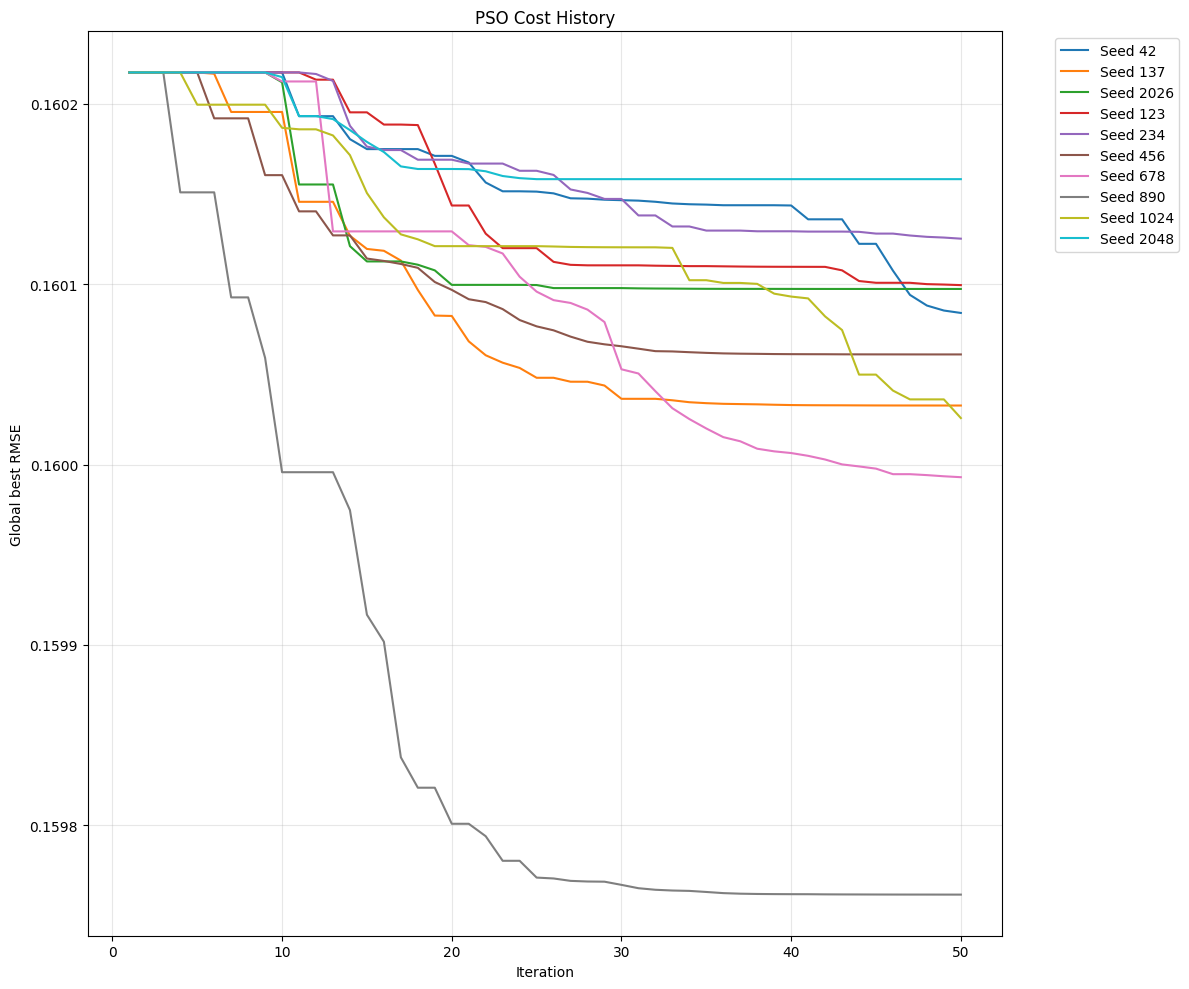

In [ ]:
# cognitive round 2 history

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("RMSE:", rmse)
print("n_pred:", (p_i_year2 > 0.5).sum(), "\n")

print("Mean p_i_year2:", p_i_year2.mean())
print("Mean S_i_year1:", S_i_year1.mean())
print("Mean C_i_year1:", C_i_year1.mean())
print("Mean E_i_year1:", E_i_year1.mean())

RMSE: 0.16029058307166952
n_pred: 10 

Mean p_i_year2: 0.009765018505051064
Mean S_i_year1: 1.0461102555366087e-05
Mean C_i_year1: 0.10117181247276968
Mean E_i_year1: 0.03231717025144201


# Round 3  more social

In [ ]:
Best RMSE: 0.15998880049203437
Best params: [ 0.89430775 54.67616978 60.40347613 28.33725364  3.31440163 35.13546371  0.86291925  0.55841463  0.46407485  0.31409819  0.56739606  0.13111821
  1.55097426  5.29001233 16.96090772  0.94065539]

In [ ]:
## more social  round 3
%%time

lower_bounds = np.array([0.5,
                         30,   10,  10,  1,  10,
                         0.1,  0.1,  0.1,  0.1,  0.1,
                         0.1,    0.5,   1,   5,    0.1,])
upper_bounds = np.array([1,
                         80, 80, 80,  80, 40,
                         1,   1,   1,   1, 1,
                         5,  10,  10, 20, 10])

bounds = (lower_bounds, upper_bounds)



seed_pos = np.array([
    0.89430775,
    54.67616978, 60.40347613, 28.33725364,  3.31440163, 35.13546371,
    0.86291925,  0.55841463,  0.46407485,  0.31409819,  0.56739606,
    0.13111821,  1.55097426,  5.29001233,  16.96090772, 0.94065539
])


options = {
    "c1": 0.7,   #cogniitive parameter
    "c2": 1.5,   # social parameter
    "w": 0.5
}


n_particles = 200
dimensions = 16
n_iterations = 50


result_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_pso_more_social_round3.csv")

history_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_pso_more_social_round3_cost_history.csv")


results = []
history_results = []


seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]


for seed in seeds:

    # Reproducible initialization for this run
    np.random.seed(seed)

    # 400 particles randomly initialized within Round 2 bounds
    init_pos = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(n_particles, dimensions)
    )


    # Using previous best fitting parameters as initial position
    init_pos[0] = np.clip(
        seed_pos,
        lower_bounds,
        upper_bounds
    )


    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=init_pos
    )


    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iterations
    )


    results.append([
        seed,
        best_cost,
        *best_pos
    ])


    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_global",

            "y_Forest",
            "y_Agriculture",
            "y_Urban",
            "y_Freshwater",
            "y_Marine",

            "e_Forest",
            "e_Agriculture",
            "e_Urban",
            "e_Freshwater",
            "e_Marine",

            "x_Forest",
            "x_Agriculture",
            "x_Urban",
            "x_Freshwater",
            "x_Marine"
        ]
    )

    #  save result
    result_df.to_csv(
        result_path,
        index=False
    )


    # save cost history
    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])


    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )


    # Save after every completed seed
    history_df.to_csv(
        history_path,
        index=False
    )


    print(f"Seed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)
    print("Initial position shape:", init_pos.shape)
    print()

2026-08-17 14:52:27,359 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 14:58:23,041 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15997695359022324, best pos: [ 0.89205214 54.6562241  60.45045114 28.51184183  1.58877593 35.13637257
  0.92617741  0.5489612   0.46756303  0.31101518  0.56716778  0.13124884
  1.55038293  5.28538012 16.96481302  0.92956296]
2026-08-17 14:58:23,107 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 42
Best RMSE: 0.15997695359022324
Best params: [ 0.89205214 54.6562241  60.45045114 28.51184183  1.58877593 35.13637257
  0.92617741  0.5489612   0.46756303  0.31101518  0.56716778  0.13124884
  1.55038293  5.28538012 16.96481302  0.92956296]
Initial position shape: (200, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 15:04:16,340 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15998880048975492, best pos: [ 0.89430775 54.67616978 60.40347613 28.33725364  3.31440163 35.13546371
  0.86291925  0.55841463  0.46407485  0.31409819  0.56739606  0.13111821
  1.55097426  5.29001233 16.96090772  0.94065539]
2026-08-17 15:04:16,414 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 137
Best RMSE: 0.15998880048975492
Best params: [ 0.89430775 54.67616978 60.40347613 28.33725364  3.31440163 35.13546371
  0.86291925  0.55841463  0.46407485  0.31409819  0.56739606  0.13111821
  1.55097426  5.29001233 16.96090772  0.94065539]
Initial position shape: (200, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 15:10:07,563 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15998297433938738, best pos: [ 0.89401497 55.52511649 60.28166527 28.28030681  5.70833449 34.80433301
  0.86162143  0.55803258  0.46490446  0.3169006   0.56665304  0.13297069
  1.56315915  5.29001521 17.26565961  0.85234049]
2026-08-17 15:10:07,619 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


...

Seed 890
Best RMSE: 0.15998880048975492
Best params: [ 0.89430775 54.67616978 60.40347613 28.33725364  3.31440163 35.13546371
  0.86291925  0.55841463  0.46407485  0.31409819  0.56739606  0.13111821
  1.55097426  5.29001233 16.96090772  0.94065539]
Initial position shape: (200, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 15:45:00,444 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15997492031454413, best pos: [ 0.89162883 54.67697348 60.40767647 28.35559443  3.3211179  35.13637186
  0.98678767  0.58963279  0.64390187  0.36235088  0.6287775   0.13170283
  1.64988451  5.26926641 16.98237205  0.94677852]
2026-08-17 15:45:00,481 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 1024
Best RMSE: 0.15997492031454413
Best params: [ 0.89162883 54.67697348 60.40767647 28.35559443  3.3211179  35.13637186
  0.98678767  0.58963279  0.64390187  0.36235088  0.6287775   0.13170283
  1.64988451  5.26926641 16.98237205  0.94677852]
Initial position shape: (200, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 15:50:49,463 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1599686742613316, best pos: [ 0.89197337 54.70910177 61.51714515 28.01399524  2.67727631 35.10663921
  0.98935657  0.58397695  0.47043697  0.32200061  0.56609416  0.13621732
  1.56055432  5.26789654 17.02756434  0.9504365 ]


Seed 2048
Best RMSE: 0.1599686742613316
Best params: [ 0.89197337 54.70910177 61.51714515 28.01399524  2.67727631 35.10663921
  0.98935657  0.58397695  0.47043697  0.32200061  0.56609416  0.13621732
  1.56055432  5.26789654 17.02756434  0.9504365 ]
Initial position shape: (200, 16)

CPU times: user 1h 29min 9s, sys: 6min 43s, total: 1h 35min 52s
Wall time: 58min 22s


In [ ]:
round1_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_cost_history.csv")

round2_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round2_cost_history.csv")

round3_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round3_cost_history.csv")

In [ ]:
history_social_all_df.head(100)

,seed,iteration,best_rmse
0,42,1,0.164512
1,42,2,0.164295
2,42,3,0.164255
3,42,4,0.164240
4,42,5,0.162011
...,...,...,...
95,137,46,0.160647
96,137,47,0.160647
97,137,48,0.160647
98,137,49,0.160647


In [ ]:
seeds = [42, 137, 2026, 123, 234,  456, 678, 890, 1024, 2048]

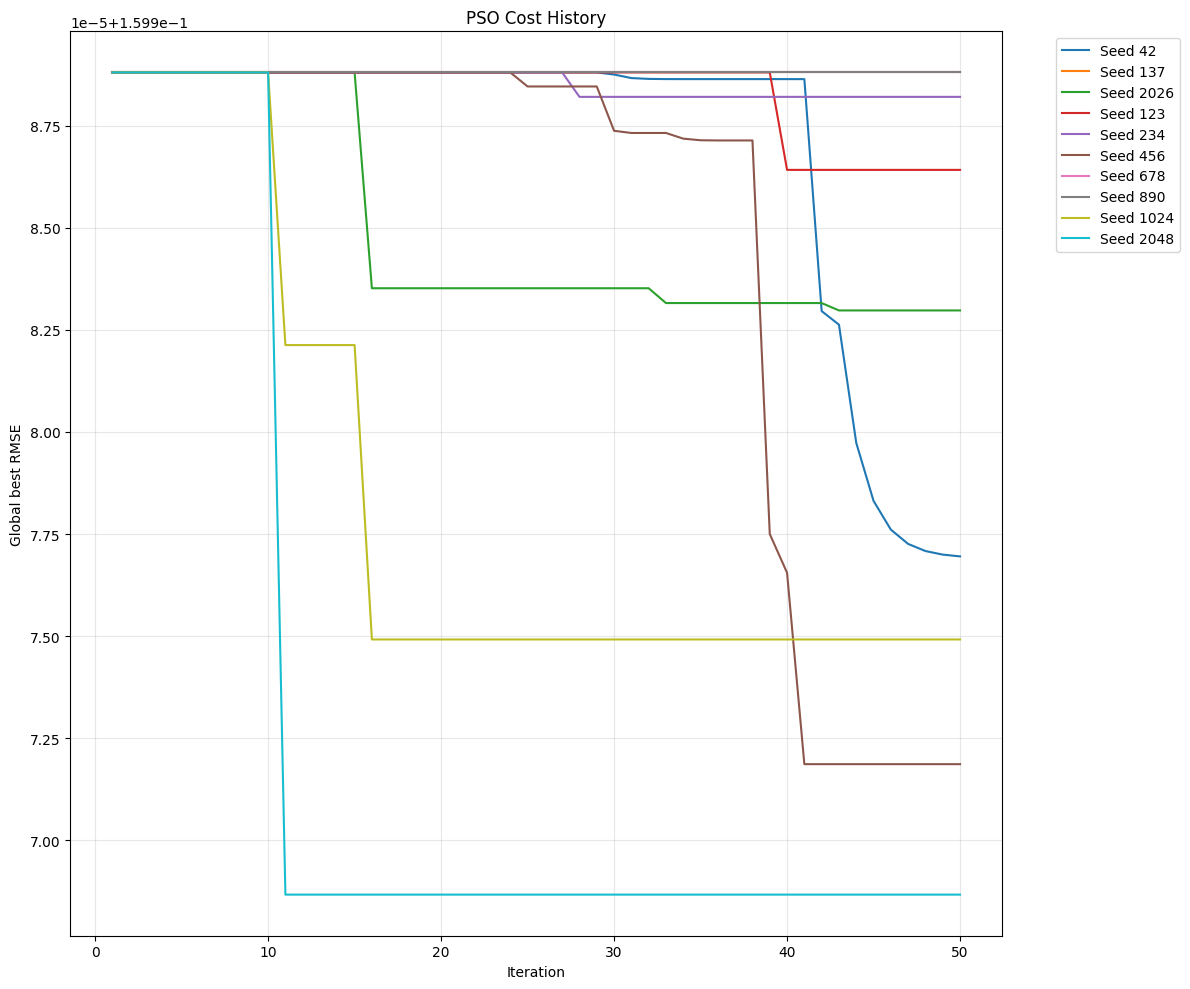

In [ ]:
# social Round 3 cost history

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = round3_soical_history[round3_soical_history["seed"] == seed]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## more cognitive round 3
%%time

lower_bounds = np.array([0.5,
                         30,   10,  10,  1,  10,
                         0.1,  0.1,  0.1,  0.1,  0.1,
                         0.1,    0.5,   1,   5,    0.1,])
upper_bounds = np.array([1,
                         80, 80, 80,  80, 40,
                         1,   1,   1,   1, 1,
                         5,  10,  10, 20, 10])

bounds = (lower_bounds, upper_bounds)



seed_pos = np.array([
    0.9207990158,
    51.79464159,	70.26272178,	34.65255105,	63.52329364,	41.17249377,
    0.9249905849,	0.5851300793,	0.4847294119,	0.250310153,	0.605043435,
    0.104325818,	1.693922761,	5.54536755,	18.08863888,	0.5474107304
])


options = {
    "c1": 1.5,   #cogniitive parameter
    "c2": 0.7,   # social parameter
    "w": 0.5
}


n_particles = 200
dimensions = 16
n_iterations = 50


result_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_pso_more_cognitive_round3.csv")

history_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_pso_more_cognitive_round3_cost_history.csv")


results = []
history_results = []


seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]


for seed in seeds:

    # Reproducible initialization for this run
    np.random.seed(seed)

    # 400 particles randomly initialized within Round 2 bounds
    init_pos = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(n_particles, dimensions)
    )


    # Using previous best fitting parameters as initial position
    init_pos[0] = np.clip(
        seed_pos,
        lower_bounds,
        upper_bounds
    )


    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=init_pos
    )


    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iterations
    )


    results.append([
        seed,
        best_cost,
        *best_pos
    ])


    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_global",

            "y_Forest",
            "y_Agriculture",
            "y_Urban",
            "y_Freshwater",
            "y_Marine",

            "e_Forest",
            "e_Agriculture",
            "e_Urban",
            "e_Freshwater",
            "e_Marine",

            "x_Forest",
            "x_Agriculture",
            "x_Urban",
            "x_Freshwater",
            "x_Marine"
        ]
    )

    #  save result
    result_df.to_csv(
        result_path,
        index=False
    )


    # save cost history
    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])


    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )


    # Save after every completed seed
    history_df.to_csv(
        history_path,
        index=False
    )


    print(f"Seed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)
    print("Initial position shape:", init_pos.shape)
    print()

2026-08-17 20:59:30,561 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 21:05:31,961 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15995308623725518, best pos: [ 0.91929404 51.79566703 70.47005771 34.80166075 62.9648757  25.87032148
  0.92762808  0.58649787  0.48434264  0.24955547  0.60479885  0.10044519
  1.69297852  5.54520522 18.07268005  0.53271118]
2026-08-17 21:05:31,999 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 42
Best RMSE: 0.15995308623725518
Best params: [ 0.91929404 51.79566703 70.47005771 34.80166075 62.9648757  25.87032148
  0.92762808  0.58649787  0.48434264  0.24955547  0.60479885  0.10044519
  1.69297852  5.54520522 18.07268005  0.53271118]
Initial position shape: (200, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 21:11:35,024 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15994146222723635, best pos: [ 0.92220703 51.79847251 70.62750056 34.8169039  63.50522202 14.08540192
  0.91613208  0.57836198  0.48492277  0.13550001  0.6129733   0.10036496
  1.70562716  5.54466256 18.20548633  0.43027975]
2026-08-17 21:11:35,060 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 137
Best RMSE: 0.15994146222723635
Best params: [ 0.92220703 51.79847251 70.62750056 34.8169039  63.50522202 14.08540192
  0.91613208  0.57836198  0.48492277  0.13550001  0.6129733   0.10036496
  1.70562716  5.54466256 18.20548633  0.43027975]
Initial position shape: (200, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 21:17:33,924 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15995564365036927, best pos: [ 0.92079902 51.79464159 70.26272178 34.65255105 63.52329364 40.
  0.92499058  0.58513008  0.48472941  0.25031015  0.60504344  0.10432582
  1.69392276  5.54536755 18.08863888  0.54741073]
2026-08-17 21:17:33,953 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


...

Seed 890
Best RMSE: 0.1599483910735582
Best params: [ 0.92775838 52.10934549 70.44737943 34.66637944 63.44056098 32.26508707
  0.96421854  0.61528288  0.49585628  0.21358382  0.61773602  0.11540468
  1.69997497  5.59189956 18.22596815  0.59509692]
Initial position shape: (200, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 21:53:45,759 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15995564365036927, best pos: [ 0.92079902 51.79464159 70.26272178 34.65255105 63.52329364 40.
  0.92499058  0.58513008  0.48472941  0.25031015  0.60504344  0.10432582
  1.69392276  5.54536755 18.08863888  0.54741073]
2026-08-17 21:53:45,824 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 1024
Best RMSE: 0.15995564365036927
Best params: [ 0.92079902 51.79464159 70.26272178 34.65255105 63.52329364 40.
  0.92499058  0.58513008  0.48472941  0.25031015  0.60504344  0.10432582
  1.69392276  5.54536755 18.08863888  0.54741073]
Initial position shape: (200, 16)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.16
2026-08-17 21:59:47,488 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.15995564365036927, best pos: [ 0.92079902 51.79464159 70.26272178 34.65255105 63.52329364 40.
  0.92499058  0.58513008  0.48472941  0.25031015  0.60504344  0.10432582
  1.69392276  5.54536755 18.08863888  0.54741073]


Seed 2048
Best RMSE: 0.15995564365036927
Best params: [ 0.92079902 51.79464159 70.26272178 34.65255105 63.52329364 40.
  0.92499058  0.58513008  0.48472941  0.25031015  0.60504344  0.10432582
  1.69392276  5.54536755 18.08863888  0.54741073]
Initial position shape: (200, 16)

CPU times: user 1h 31min 41s, sys: 7min 47s, total: 1h 39min 28s
Wall time: 1h 16s


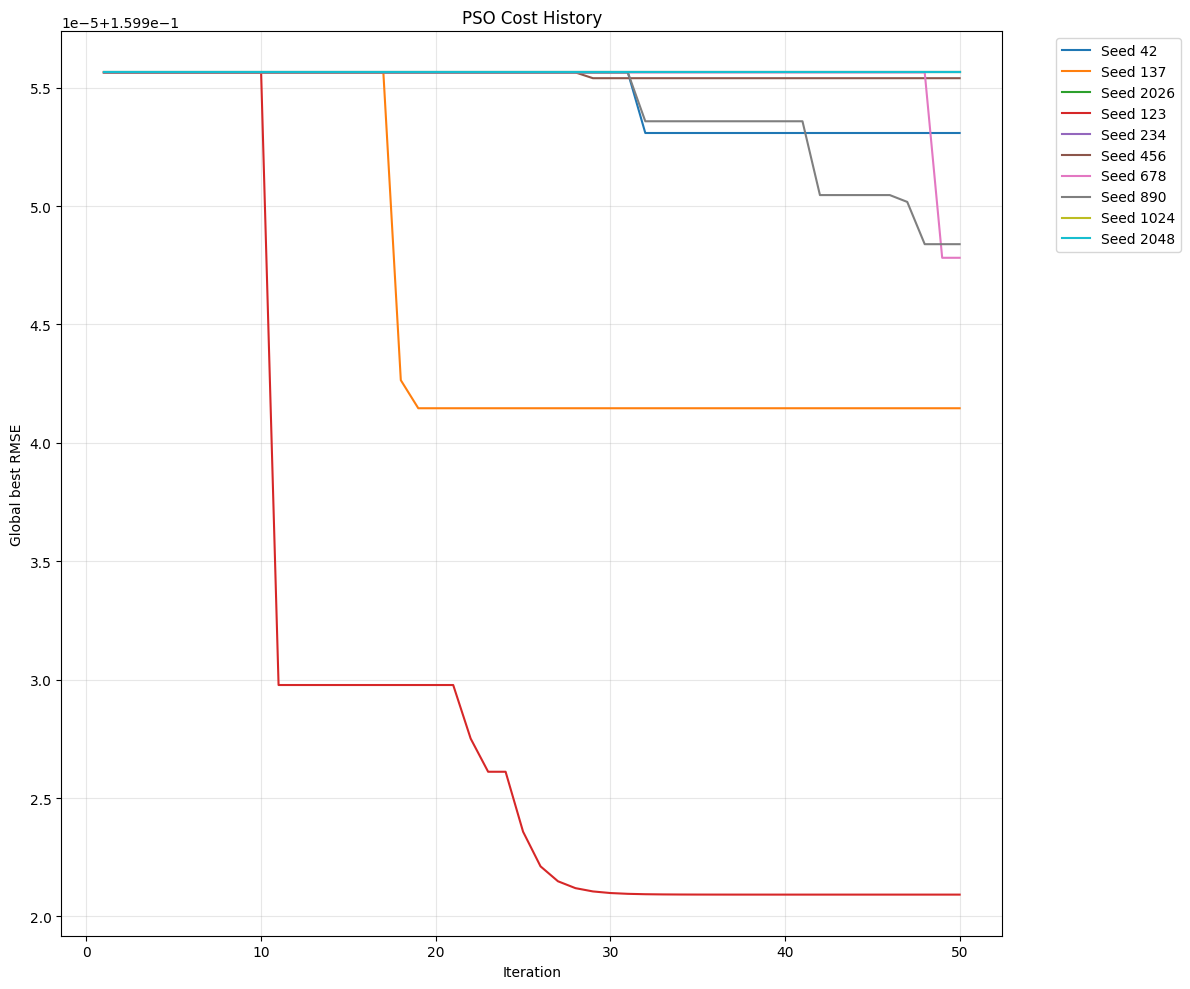

In [ ]:
#  more cognitive round 3 history

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(*best_pos)


print("RMSE:", rmse)
print("n_pred:", (p_i_year2 > 0.5).sum(), "\n")

print("Mean p_i_year2:", p_i_year2.mean())
print("Mean S_i_year1:", S_i_year1.mean())
print("Mean C_i_year1:", C_i_year1.mean())
print("Mean E_i_year1:", E_i_year1.mean())


RMSE: 0.15995564365036927
n_pred: 10 

Mean p_i_year2: 0.008449612336787905
Mean S_i_year1: 0.001221618121844847
Mean C_i_year1: 8.270185280596835e-08
Mean E_i_year1: 0.09120590593519243


#------------------------------------------------------
#Plot cost history

In [ ]:
round1_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_cost_history.csv")

round2_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round2_cost_history.csv")

round3_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round3_cost_history.csv")


r1 = round1_soical_history.copy()
r2 = round2_soical_history.copy()
r3 = round3_soical_history.copy()


r2["iteration"] += r1["iteration"].max()
r3["iteration"] += r1["iteration"].max() + round2_soical_history["iteration"].max()


history_social_all_df = (
    pd.concat([r1, r2, r3], ignore_index=True)
      .sort_values(["seed", "iteration"])
      .reset_index(drop=True)
)

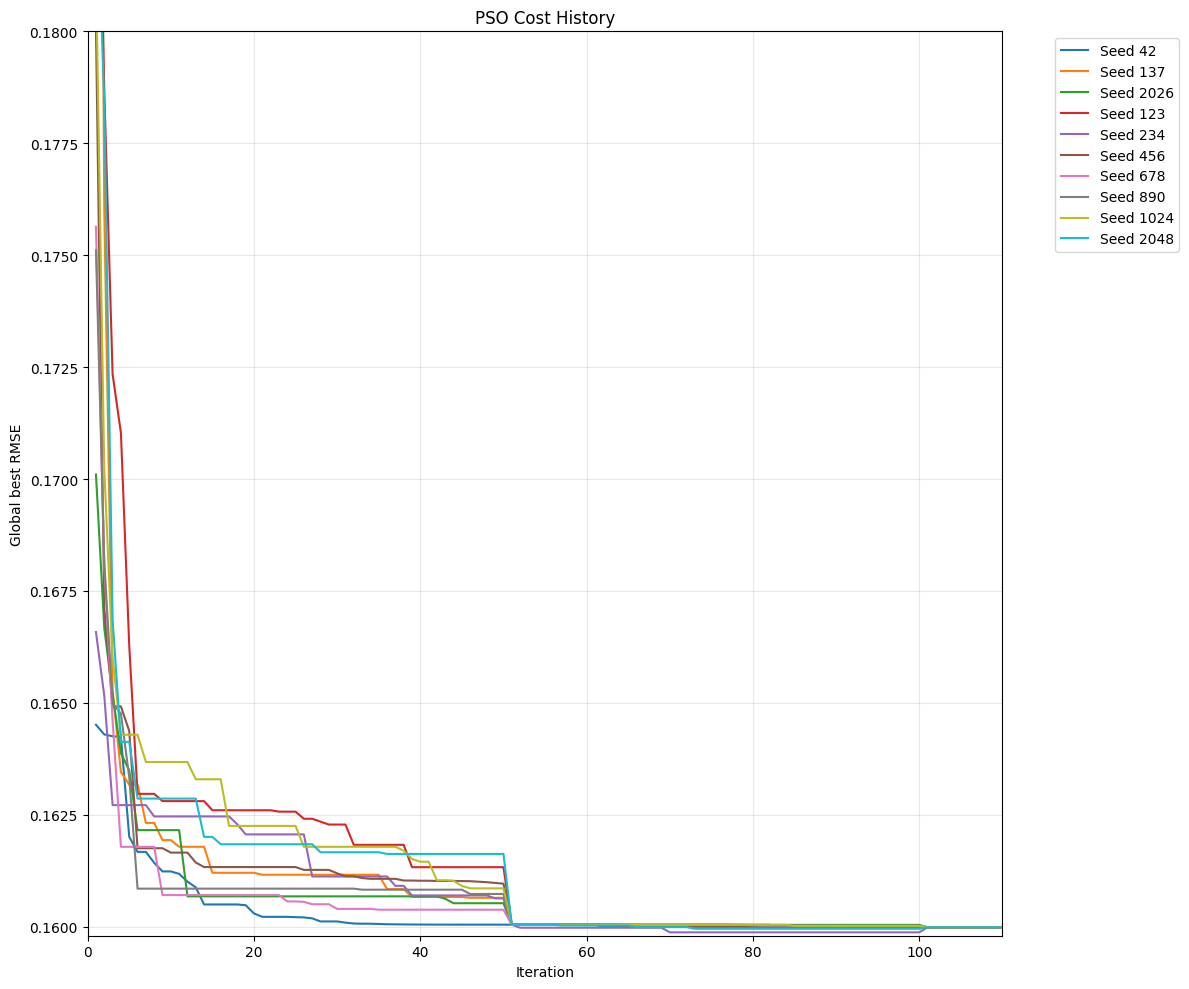

In [ ]:
# All more social history

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_social_all_df[
        history_social_all_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.ylim(0.1598, 0.18)
plt.xlim(0, 110)


plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

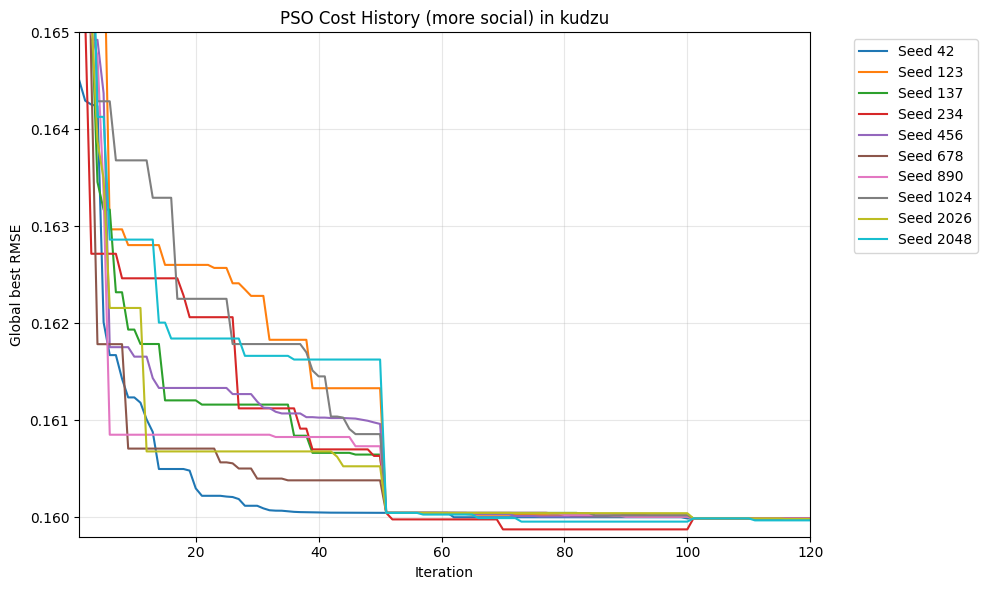

In [ ]:
plt.figure(figsize=(10, 6))

for seed, group in history_social_all_df.groupby("seed"):
    plt.plot(
        group["iteration"],
        group["best_rmse"],
        label=f"Seed {seed}"
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History (more social) in kudzu")

plt.ylim(0.1598, 0.165)
plt.xlim(1, 120)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
## more cognitive all cost history

round1_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_cost_history.csv")

round2_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round2_cost_history.csv")

round3_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round3_cost_history.csv")


r1 = round1_soical_history.copy()
r2 = round2_soical_history.copy()
r3 = round3_soical_history.copy()


r2["iteration"] += r1["iteration"].max()
r3["iteration"] += r1["iteration"].max() + round2_soical_history["iteration"].max()


history_social_all_df = (
    pd.concat([r1, r2, r3], ignore_index=True)
      .sort_values(["seed", "iteration"])
      .reset_index(drop=True)
)


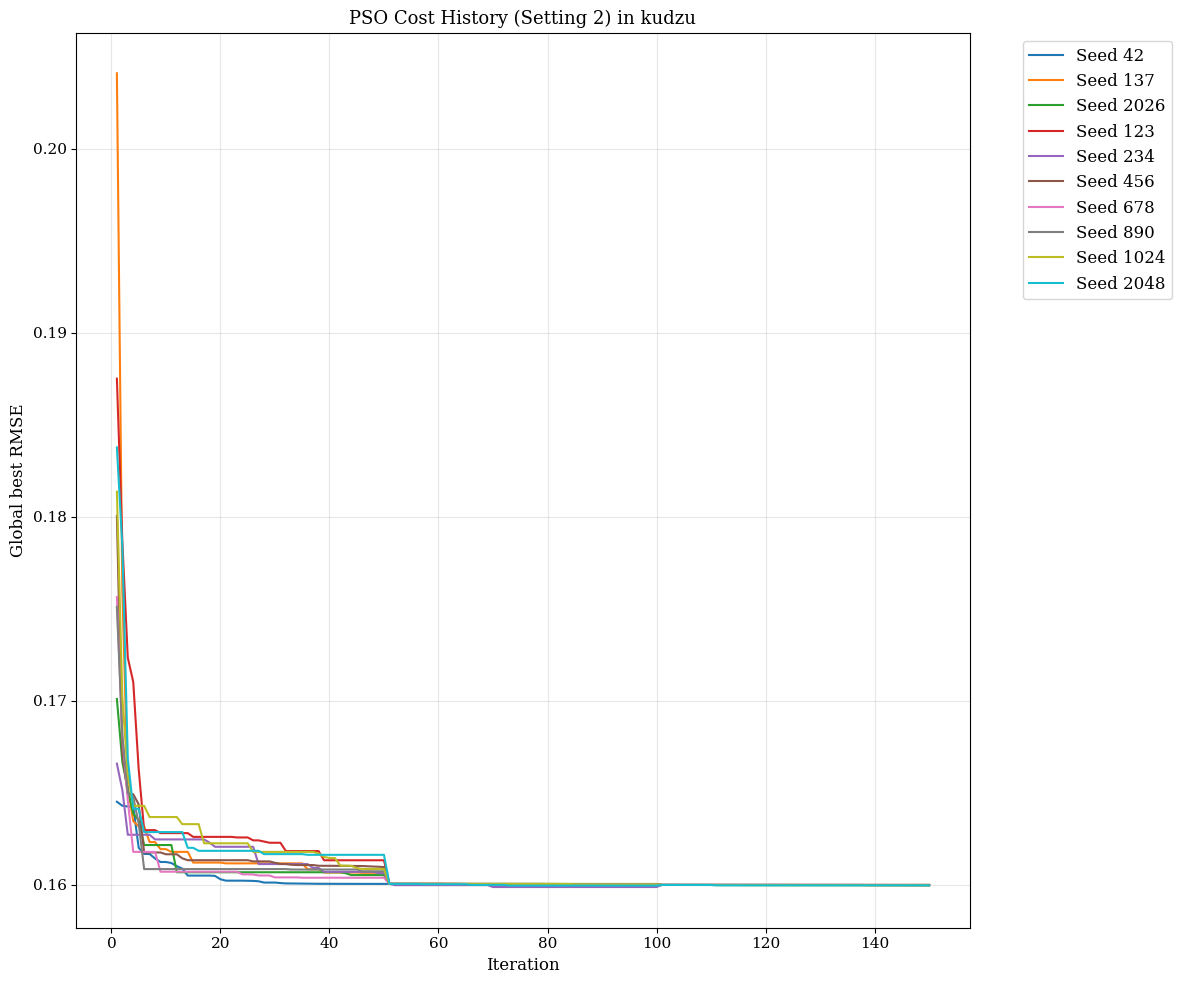

In [ ]:
# All more social history

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_social_all_df[
        history_social_all_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History (Setting 2) in kudzu")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

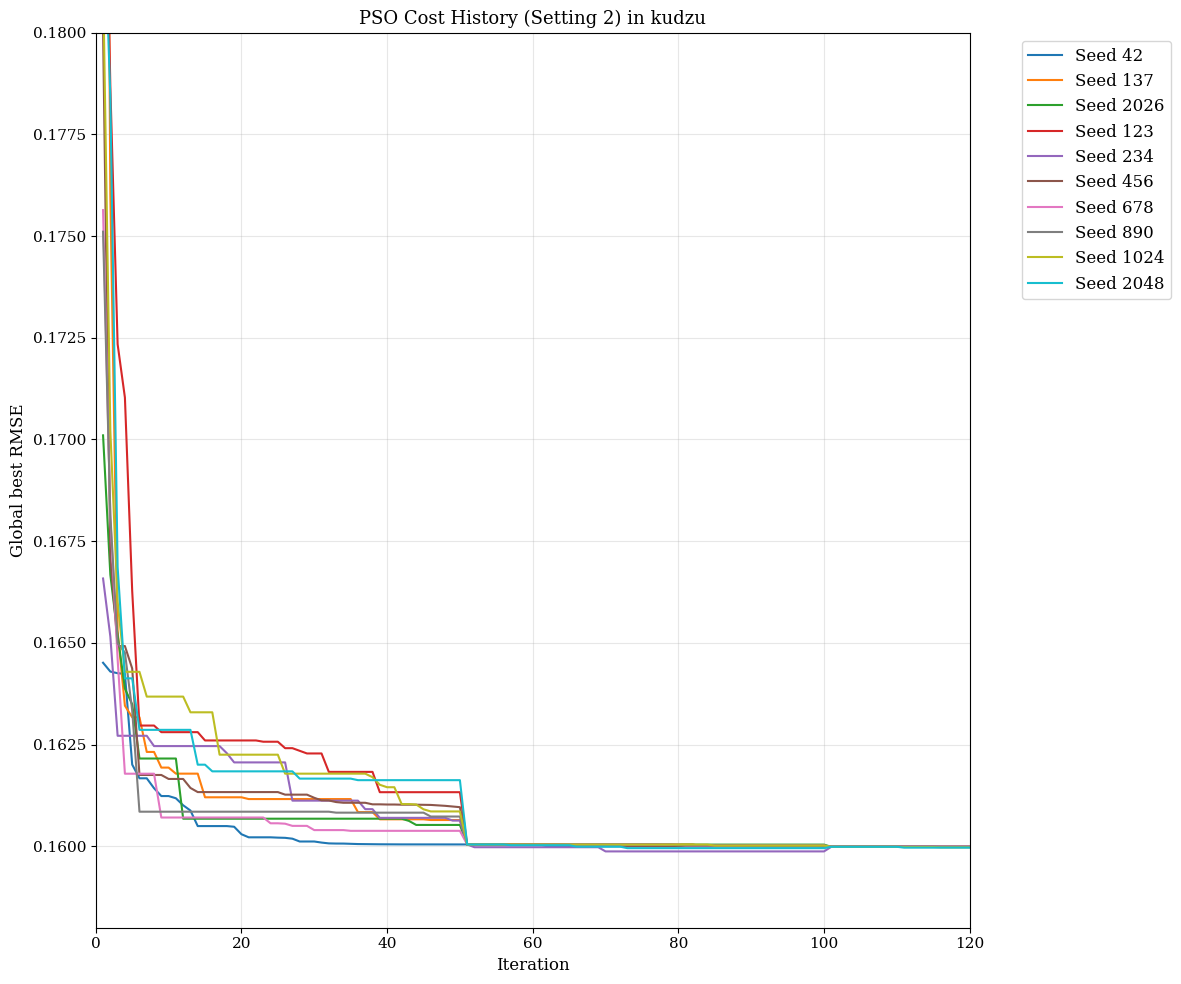

In [ ]:
# All more social history

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_social_all_df[
        history_social_all_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History (Setting 2) in kudzu")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.ylim(0.158, 0.18)
plt.xlim(0, 120)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

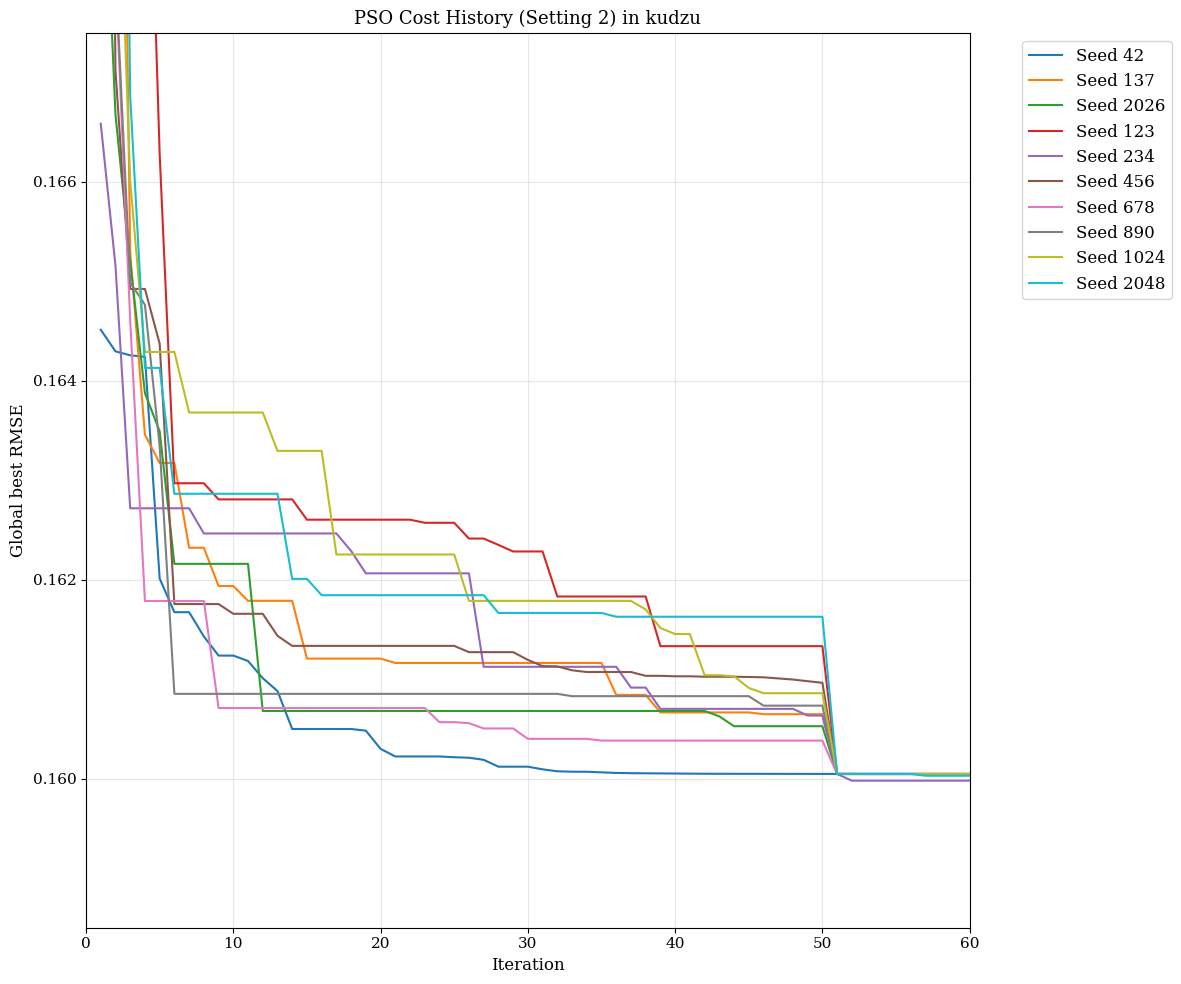

In [ ]:
# All more social history

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_social_all_df[
        history_social_all_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History (Setting 2) in kudzu")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.ylim(0.1585, 0.1675)
plt.xlim(0, 60)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



---



In [ ]:
## more cognitive all cost history

round1_cognitive_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive_cost_history.csv")

round2_cognitive_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive_round2_cost_history.csv")

round3_cognitive_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive_round3_cost_history.csv")


r1 = round1_cognitive_history.copy()
r2 = round2_cognitive_history.copy()
r3 = round3_cognitive_history.copy()


r2["iteration"] += r1["iteration"].max()
r3["iteration"] += r1["iteration"].max() + round2_cognitive_history["iteration"].max()


history_cognitive_all_df = (
    pd.concat([r1, r2, r3], ignore_index=True)
      .sort_values(["seed", "iteration"])
      .reset_index(drop=True)
)


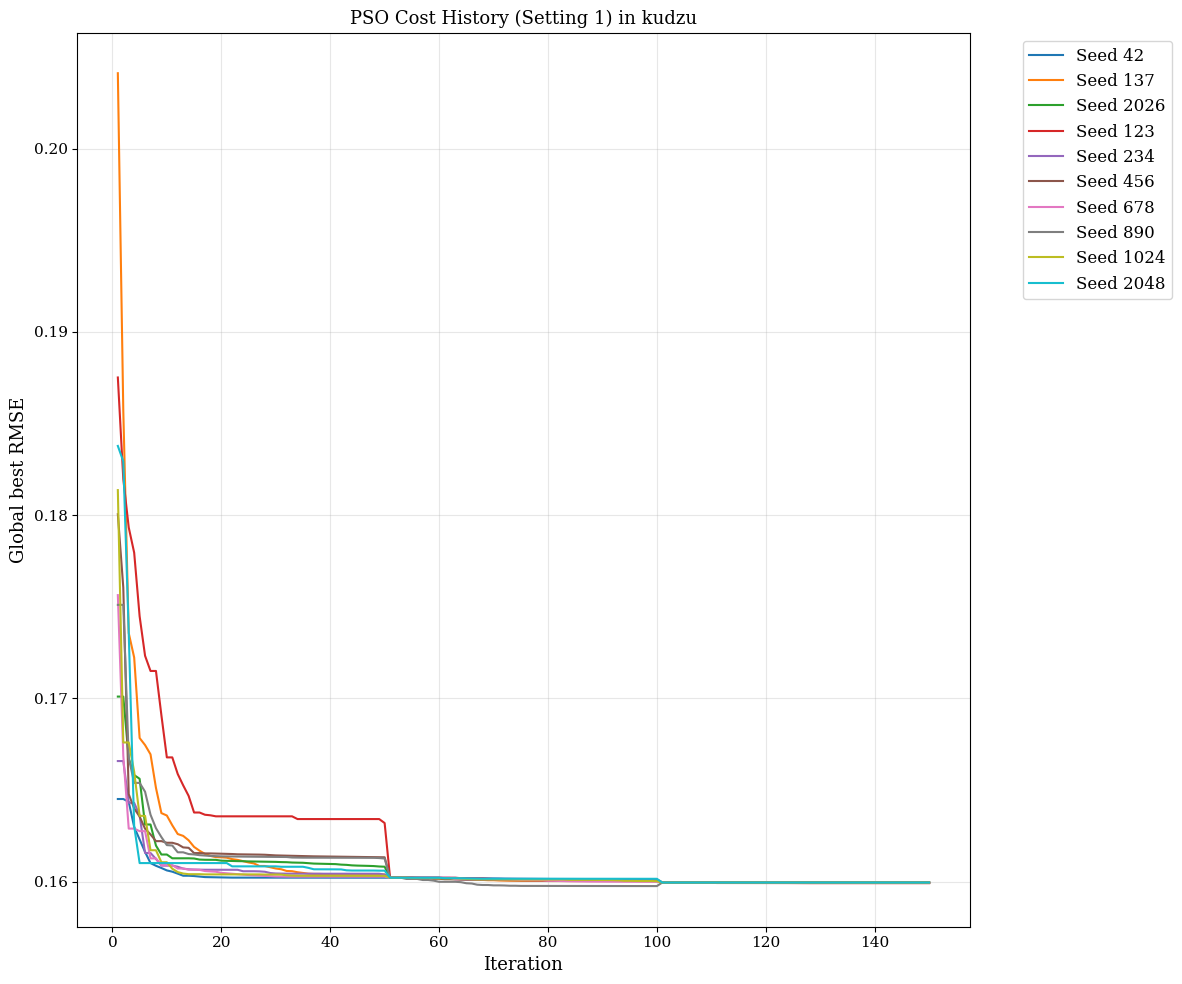

In [ ]:
# All more cognitive history
seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_cognitive_all_df[
        history_cognitive_all_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration", fontsize = 13)
plt.ylabel("Global best RMSE",fontsize = 13)
plt.title("PSO Cost History (Setting 1) in kudzu", fontsize = 13)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Plot all history

In [ ]:
history_cognitive_all_df["Setting"] = "S1"
history_social_all_df["Setting"] = "S2"

history_all_df = pd.concat([
    history_cognitive_all_df,
    history_social_all_df
], ignore_index=True)

In [ ]:
history_all_df.head()

,seed,iteration,best_rmse,Setting
0,42,1,0.164512,S1
1,42,2,0.164512,S1
2,42,3,0.164360,S1
3,42,4,0.162985,S1
4,42,5,0.162301,S1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
history_all_df = pd.read.csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_all_cost_history.csv")

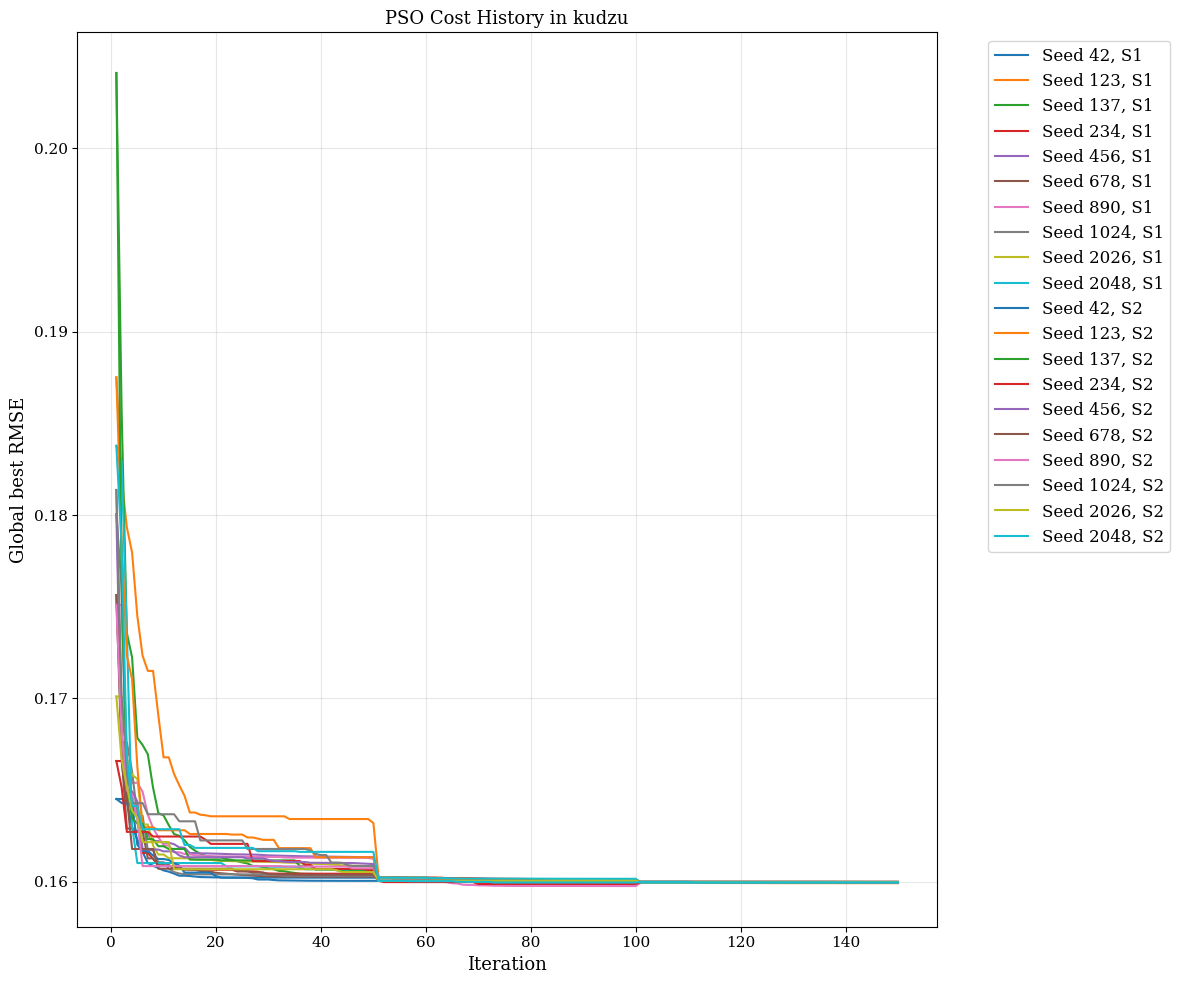

In [ ]:
plt.figure(figsize=(12, 10))

for (setting, seed), df_seed in history_all_df.groupby(["Setting", "seed"]):
    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}, {setting}",
        linewidth=1.5
    )

plt.xlabel("Iteration", fontsize=13)
plt.ylabel("Global best RMSE", fontsize=13)
plt.title("PSO Cost History in kudzu", fontsize=13)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xlim(0, 120)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

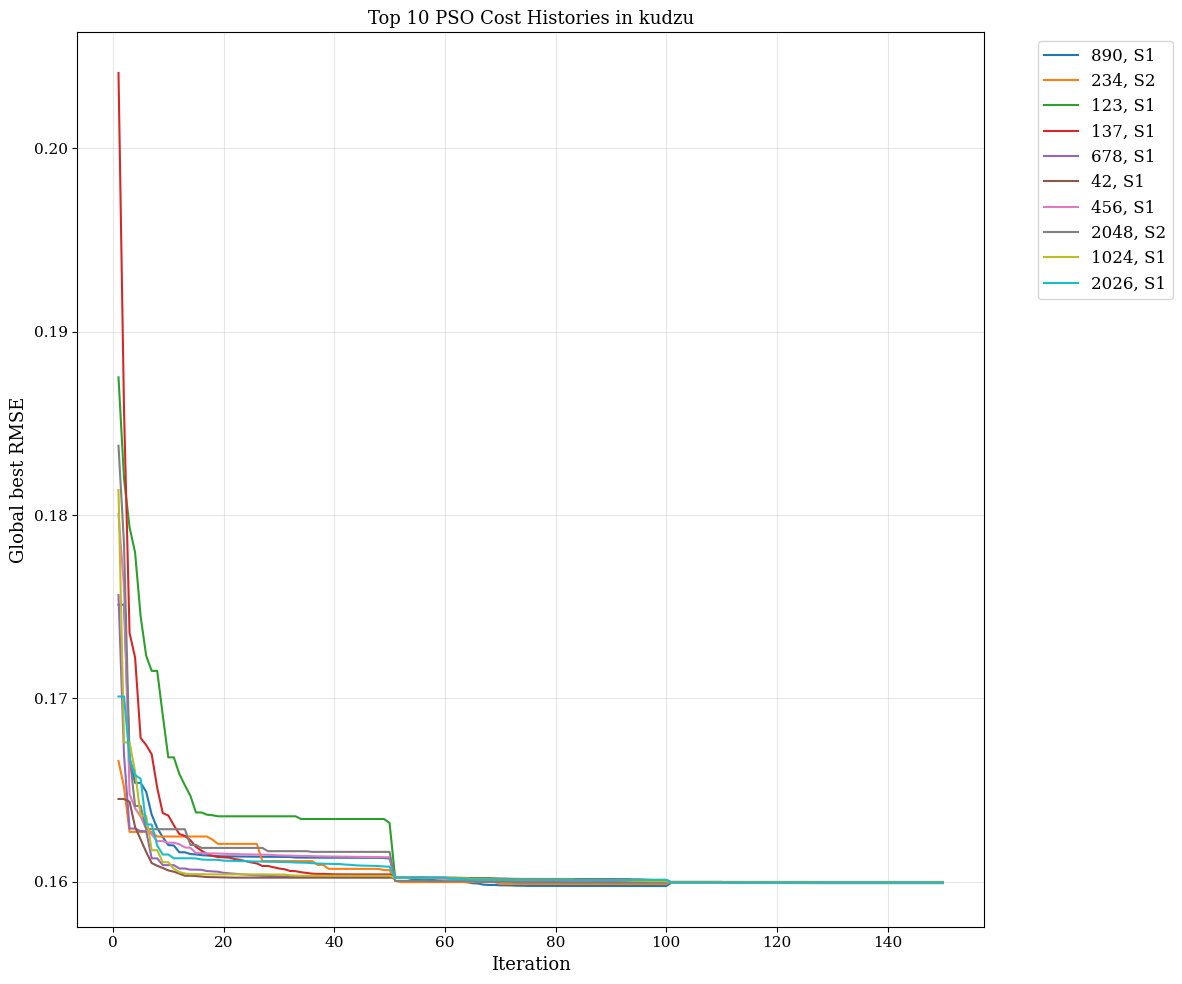

In [ ]:
# Select top 10 PSO runs by best RMSE
top10_runs = (
    history_all_df
    .groupby(["Setting", "seed"])["best_rmse"]
    .min()
    .reset_index()
    .sort_values("best_rmse")
    .head(10)
)

plt.figure(figsize=(12, 10))

for _, row in top10_runs.iterrows():
    setting = row["Setting"]
    seed = row["seed"]

    df_seed = history_all_df[
        (history_all_df["Setting"] == setting) &
        (history_all_df["seed"] == seed)
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"{seed}, {setting}",
        linewidth=1.5
    )

plt.xlabel("Iteration", fontsize=13)
plt.ylabel("Global best RMSE", fontsize=13)
plt.title("Top 10 PSO Cost Histories in kudzu", fontsize=13)

plt.legend( bbox_to_anchor=(1.05, 1), loc="upper left")

# plt.ylim(0.1585, 0.1605)
# plt.xlim(100, 160)


plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#------------------------------------------------------------------------
# Projection

In [ ]:
###    More Cognitive   ####
# Round 1
round1_social_result = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social.csv")

# Round 2
round2_social_result = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round2.csv"
)

# Round 3
round3_social_result = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round3.csv")

In [ ]:
###   Social  ####
round1_social_result["round"] = 1
round2_social_result["round"] = 2
round3_social_result["round"] = 3

social_all_results = pd.concat(
    [
        round1_social_result,
        round2_social_result,
        round3_social_result
    ],
    ignore_index=True
)

In [ ]:
### BEST More social  ####
best_social_result = social_all_results.loc[
    social_all_results["rmse"].idxmin()]

best_social_result

,14
seed,234.000000
rmse,0.159876
alpha_global,0.964663
y_Forest,61.423464
y_Agriculture,73.808220
y_Urban,18.619890
y_Freshwater,9.596966
y_Marine,27.728983
e_Forest,0.895810
e_Agriculture,0.811832


In [ ]:
### BEST Social Parameter Table ####

param_table = pd.DataFrame({
    "y": [
        best_social_result["y_Forest"],
        best_social_result["y_Agriculture"],
        best_social_result["y_Urban"],
        best_social_result["y_Freshwater"],
        best_social_result["y_Marine"]
    ],
    "e": [
        best_social_result["e_Forest"],
        best_social_result["e_Agriculture"],
        best_social_result["e_Urban"],
        best_social_result["e_Freshwater"],
        best_social_result["e_Marine"]
    ],
    "x": [
        best_social_result["x_Forest"],
        best_social_result["x_Agriculture"],
        best_social_result["x_Urban"],
        best_social_result["x_Freshwater"],
        best_social_result["x_Marine"]
    ]
}, index=[
    "Forest",
    "Agriculture",
    "Urban",
    "Freshwater",
    "Marine"
])

param_table

,y,e,x
Forest,61.423464,0.895810,0.135829
Agriculture,73.808220,0.811832,1.656874
Urban,18.619890,0.810778,5.988263
Freshwater,9.596966,0.623548,18.705166
Marine,27.728983,0.882891,0.511868


In [ ]:
print(param_table)

                     y         e          x
Forest       61.423464  0.895810   0.135829
Agriculture  73.808220  0.811832   1.656874
Urban        18.619890  0.810778   5.988263
Freshwater    9.596966  0.623548  18.705166
Marine       27.728983  0.882891   0.511868


In [ ]:
###    More social   ####
## IFM future projection

def run_ifm_forecast(
    alpha_global,
    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,
    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,
    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine,
    n_steps
):

    y_i = (
        Forest_prop * y_Forest
        + Agriculture_prop * y_Agriculture
        + Urban_prop * y_Urban
        + Freshwater_prop * y_Freshwater
        + Marine_prop * y_Marine
    )

    e_i = (
        Forest_prop * e_Forest
        + Agriculture_prop * e_Agriculture
        + Urban_prop * e_Urban
        + Freshwater_prop * e_Freshwater
        + Marine_prop * e_Marine
    )

    x_i = (
        Forest_prop * x_Forest
        + Agriculture_prop * x_Agriculture
        + Urban_prop * x_Urban
        + Freshwater_prop * x_Freshwater
        + Marine_prop * x_Marine
    )

    K_ij = np.exp(-alpha_global * D_ij)
    np.fill_diagonal(K_ij, 0.0)

    E_i = np.minimum(e_i / (A_j ** x_i), 1.0)

    p_current = patch_df["occyear2"].to_numpy()

    forecast_results = []

    # Future projection
    for step in range(1, n_steps + 1):


        S_i = K_ij @ (p_current * A_j)

        C_i = S_i ** 2 / (S_i ** 2 + y_i ** 2)

        # Occupancy probability at next time step
        p_next = C_i / (C_i + (1 - C_i) * E_i)

        forecast_results.append(
            (step, p_next)
        )

        p_current = p_next

    return forecast_results

In [ ]:
### Social Forecast ####

social_forecast_results = run_ifm_forecast(

    alpha_global=best_social_result["alpha_global"],

    y_Forest=best_social_result["y_Forest"],
    y_Agriculture=best_social_result["y_Agriculture"],
    y_Urban=best_social_result["y_Urban"],
    y_Freshwater=best_social_result["y_Freshwater"],
    y_Marine=best_social_result["y_Marine"],

    e_Forest=best_social_result["e_Forest"],
    e_Agriculture=best_social_result["e_Agriculture"],
    e_Urban=best_social_result["e_Urban"],
    e_Freshwater=best_social_result["e_Freshwater"],
    e_Marine=best_social_result["e_Marine"],

    x_Forest=best_social_result["x_Forest"],
    x_Agriculture=best_social_result["x_Agriculture"],
    x_Urban=best_social_result["x_Urban"],
    x_Freshwater=best_social_result["x_Freshwater"],
    x_Marine=best_social_result["x_Marine"],

    n_steps=100
)

In [ ]:
###  more  socia   ####

print(f"{'Step':<6}"
      f"{'>=25%':<10}"
      f"{'>=50%':<10}"
      f"{'>=70%':<10}"
      f"{'~100%':<10}"
)

for step, p_next in social_forecast_results:

    n_25 = (p_next >= 0.25).sum()
    n_50 = (p_next >= 0.50).sum()
    n_70 = (p_next >= 0.70).sum()
    n_100 = (p_next >= 0.9999).sum()

    print(
        f"{step:<6}"
        f"{n_25:<10}"
        f"{n_50:<10}"
        f"{n_70:<10}"
        f"{n_100:<10}"
    )

Step  >=25%     >=50%     >=70%     ~100%     
1     17        16        15        6         
2     21        16        16        8         
3     24        18        18        8         
4     25        21        20        9         
5     25        21        20        9         
6     25        21        21        9         
7     25        21        21        9         
8     25        21        21        9         
9     25        21        21        9         
10    25        21        21        9         
11    25        21        21        9         
12    25        21        21        9         
13    25        21        21        9         
14    25        21        21        9         
15    25        21        21        9         
16    25        21        21        9         
17    25        21        21        9         
18    25        21        21        9         
19    25        21        21        9         
20    25        21        21        9         
21    25     



---



    alpha_global

    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,

    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,

    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine


In [ ]:
##########################################
###    More Cognitive   ####
##########################################

In [ ]:
###    More Cognitive   ####
# Round 1
round1_cognitive_result = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive.csv"
)

# Round 2
round2_cognitive_result = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive_round2.csv"
)

# Round 3
round3_cognitive_result = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_cognitive_round3.csv"
)

In [ ]:
###    More Cognitive   ####
round1_cognitive_result["round"] = 1
round2_cognitive_result["round"] = 2
round3_cognitive_result["round"] = 3

cognitive_all_results = pd.concat(
    [
        round1_cognitive_result,
        round2_cognitive_result,
        round3_cognitive_result
    ],
    ignore_index=True
)

In [ ]:
###    More Cognitive   ####
best_cognitive_result = cognitive_all_results.loc[
    cognitive_all_results["rmse"].idxmin()
]

best_cognitive_result

,17
seed,890.000000
rmse,0.159762
alpha_global,0.880280
y_Forest,77.137635
y_Agriculture,43.593955
y_Urban,62.451057
y_Freshwater,20.313617
y_Marine,60.029642
e_Forest,1.242422
e_Agriculture,0.898008


In [ ]:
###    More social   ####
## IFM future projection

def run_ifm_forecast(
    alpha_global,
    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,
    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,
    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine,
    n_steps
):

    y_i = (
        Forest_prop * y_Forest
        + Agriculture_prop * y_Agriculture
        + Urban_prop * y_Urban
        + Freshwater_prop * y_Freshwater
        + Marine_prop * y_Marine
    )

    e_i = (
        Forest_prop * e_Forest
        + Agriculture_prop * e_Agriculture
        + Urban_prop * e_Urban
        + Freshwater_prop * e_Freshwater
        + Marine_prop * e_Marine
    )

    x_i = (
        Forest_prop * x_Forest
        + Agriculture_prop * x_Agriculture
        + Urban_prop * x_Urban
        + Freshwater_prop * x_Freshwater
        + Marine_prop * x_Marine
    )

    K_ij = np.exp(-alpha_global * D_ij)
    np.fill_diagonal(K_ij, 0.0)

    E_i = np.minimum(e_i / (A_j ** x_i), 1.0)

    p_current = patch_df["occyear2"].to_numpy()

    forecast_results = []

    # Projection
    for step in range(1, n_steps + 1):


        S_i = K_ij @ (p_current * A_j)

        C_i = S_i ** 2 / (S_i ** 2 + y_i ** 2)

        p_next = C_i / (C_i + (1 - C_i) * E_i)

        forecast_results.append(
            (step, p_next)
        )

        p_current = p_next

    return forecast_results

In [ ]:
### Cognitive ####

forecast_results = run_ifm_forecast(

    alpha_global=best_cognitive_result["alpha_global"],

    y_Forest=best_cognitive_result["y_Forest"],
    y_Agriculture=best_cognitive_result["y_Agriculture"],
    y_Urban=best_cognitive_result["y_Urban"],
    y_Freshwater=best_cognitive_result["y_Freshwater"],
    y_Marine=best_cognitive_result["y_Marine"],

    e_Forest=best_cognitive_result["e_Forest"],
    e_Agriculture=best_cognitive_result["e_Agriculture"],
    e_Urban=best_cognitive_result["e_Urban"],
    e_Freshwater=best_cognitive_result["e_Freshwater"],
    e_Marine=best_cognitive_result["e_Marine"],

    x_Forest=best_cognitive_result["x_Forest"],
    x_Agriculture=best_cognitive_result["x_Agriculture"],
    x_Urban=best_cognitive_result["x_Urban"],
    x_Freshwater=best_cognitive_result["x_Freshwater"],
    x_Marine=best_cognitive_result["x_Marine"],

    n_steps=100
)

In [ ]:
###    More Cognitive   ####

print(f"{'Step':<6}"
      f"{'>=25%':<10}"
      f"{'>=50%':<10}"
      f"{'>=70%':<10}"
      f"{'~100%':<10}"
)

for step, p_next in forecast_results:

    n_25 = (p_next >= 0.25).sum()
    n_50 = (p_next >= 0.50).sum()
    n_70 = (p_next >= 0.70).sum()
    n_100 = (p_next >= 0.9999).sum()

    print(
        f"{step:<6}"
        f"{n_25:<10}"
        f"{n_50:<10}"
        f"{n_70:<10}"
        f"{n_100:<10}"
    )

Step  >=25%     >=50%     >=70%     ~100%     
1     17        17        15        7         
2     21        18        16        8         
3     25        21        19        9         
4     27        23        20        10        
5     27        23        21        10        
6     27        23        21        10        
7     27        24        21        10        
8     27        24        21        10        
9     27        24        21        10        
10    27        24        21        10        
11    27        24        21        10        
12    27        24        21        10        
13    27        24        21        10        
14    27        24        21        10        
15    27        24        21        10        
16    27        24        21        10        
17    27        24        22        10        
18    27        24        22        10        
19    27        24        22        10        
20    27        24        22        10        
21    27     

In [ ]:
round1_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_cost_history.csv")

round2_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round2_cost_history.csv")

round3_soical_history = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_more_social_round3_cost_history.csv")


r1 = round1_soical_history.copy()
r2 = round2_soical_history.copy()
r3 = round3_soical_history.copy()


r2["iteration"] += r1["iteration"].max()
r3["iteration"] += r1["iteration"].max() + round2_soical_history["iteration"].max()


history_social_pso_all_df = (
    pd.concat([r1, r2, r3], ignore_index=True)
      .sort_values(["seed", "iteration"])
      .reset_index(drop=True)
)



---



# Sort all results

In [ ]:
### Add Setting Column ####

cognitive_all_results["setting"] = "Setting 1"
social_all_results["setting"] = "Setting 2"

In [ ]:
### Sort Cognitive Results ####

cognitive_all_results_sorted = cognitive_all_results.sort_values(
    by="rmse",
    ascending=True
).reset_index(drop=True)

cognitive_all_results_sorted

,seed,rmse,alpha_global,y_Forest,y_Agriculture,y_Urban,y_Freshwater,y_Marine,e_Forest,e_Agriculture,e_Urban,e_Freshwater,e_Marine,x_Forest,x_Agriculture,x_Urban,x_Freshwater,x_Marine,round,setting
0,890,0.159762,0.880280,77.137635,43.593955,62.451057,20.313617,60.029642,1.242422,0.898008,0.968765,0.420957,0.776099,0.050033,1.619772,5.563152,18.206449,1.190086,2,Setting 1
1,123,0.159921,0.968525,51.517422,68.785684,39.917364,43.580847,26.429079,0.835689,0.690462,0.568037,0.372933,0.579873,0.106334,2.080781,5.652431,18.997204,0.755330,3,Setting 1
2,137,0.159941,0.922207,51.798473,70.627501,34.816904,63.505222,14.085402,0.916132,0.578362,0.484923,0.135500,0.612973,0.100365,1.705627,5.544663,18.205486,0.430280,3,Setting 1
3,678,0.159948,0.932628,51.716278,71.868695,34.327709,64.804521,13.820073,0.915377,0.585608,0.497358,0.251106,0.604758,0.122719,1.701163,5.639630,18.729895,0.560001,3,Setting 1
4,890,0.159948,0.927758,52.109345,70.447379,34.666379,63.440561,32.265087,0.964219,0.615283,0.495856,0.213584,0.617736,0.115405,1.699975,5.591900,18.225968,0.595097,3,Setting 1
5,42,0.159953,0.919294,51.795667,70.470058,34.801661,62.964876,25.870321,0.927628,0.586498,0.484343,0.249555,0.604799,0.100445,1.692979,5.545205,18.072680,0.532711,3,Setting 1
6,456,0.159955,0.921297,51.797071,70.213552,34.661827,63.568896,11.096799,0.928269,0.589270,0.485562,0.252071,0.606836,0.101431,1.689747,5.584008,18.105152,0.531467,3,Setting 1
7,2026,0.159956,0.920799,51.794642,70.262722,34.652551,63.523294,40.000000,0.924991,0.585130,0.484729,0.250310,0.605043,0.104326,1.693923,5.545368,18.088639,0.547411,3,Setting 1
8,2048,0.159956,0.920799,51.794642,70.262722,34.652551,63.523294,40.000000,0.924991,0.585130,0.484729,0.250310,0.605043,0.104326,1.693923,5.545368,18.088639,0.547411,3,Setting 1
9,234,0.159956,0.920799,51.794642,70.262722,34.652551,63.523294,40.000000,0.924991,0.585130,0.484729,0.250310,0.605043,0.104326,1.693923,5.545368,18.088639,0.547411,3,Setting 1


In [ ]:
### Sort Social Results ####

social_all_results_sorted = social_all_results.sort_values(
    by="rmse",
    ascending=True
).reset_index(drop=True)

social_all_results_sorted

,seed,rmse,alpha_global,y_Forest,y_Agriculture,y_Urban,y_Freshwater,y_Marine,e_Forest,e_Agriculture,e_Urban,e_Freshwater,e_Marine,x_Forest,x_Agriculture,x_Urban,x_Freshwater,x_Marine,round,setting
0,234,0.159876,0.964663,61.423464,73.808220,18.619890,9.596966,27.728983,0.895810,0.811832,0.810778,0.623548,0.882891,0.135829,1.656874,5.988263,18.705166,0.511868,2,Setting 2
1,2048,0.159956,0.920799,51.794642,70.262722,34.652551,63.523294,41.172494,0.924991,0.585130,0.484729,0.250310,0.605043,0.104326,1.693923,5.545368,18.088639,0.547411,2,Setting 2
2,2048,0.159969,0.891973,54.709102,61.517145,28.013995,2.677276,35.106639,0.989357,0.583977,0.470437,0.322001,0.566094,0.136217,1.560554,5.267897,17.027564,0.950436,3,Setting 2
3,456,0.159972,0.894370,54.580352,59.518900,27.733785,2.925604,34.493982,0.879598,0.565538,0.464600,0.311635,0.574418,0.102588,1.560726,5.310801,16.950930,0.972557,3,Setting 2
4,1024,0.159975,0.891629,54.676973,60.407676,28.355594,3.321118,35.136372,0.986788,0.589633,0.643902,0.362351,0.628777,0.131703,1.649885,5.269266,16.982372,0.946779,3,Setting 2
5,42,0.159977,0.892052,54.656224,60.450451,28.511842,1.588776,35.136373,0.926177,0.548961,0.467563,0.311015,0.567168,0.131249,1.550383,5.285380,16.964813,0.929563,3,Setting 2
6,2026,0.159983,0.894015,55.525116,60.281665,28.280307,5.708334,34.804333,0.861621,0.558033,0.464904,0.316901,0.566653,0.132971,1.563159,5.290015,17.265660,0.852340,3,Setting 2
7,123,0.159986,0.893947,54.676370,60.410881,28.324945,1.006554,35.134878,0.862900,0.558418,0.464086,0.313585,0.567241,0.131513,1.552744,5.289500,16.961911,0.940624,3,Setting 2
8,234,0.159988,0.896374,54.796929,60.187985,28.317265,3.289388,33.038075,0.862823,0.556821,0.469534,0.314022,0.537822,0.134168,1.570731,5.288914,16.999335,0.938035,3,Setting 2
9,137,0.159989,0.894308,54.676170,60.403476,28.337254,3.314402,35.135464,0.862919,0.558415,0.464075,0.314098,0.567396,0.131118,1.550974,5.290012,16.960908,0.940655,3,Setting 2


In [ ]:
all_results_sorted = pd.concat(
    [
        cognitive_all_results,
        social_all_results
    ],
    ignore_index=True
).sort_values(
    by="rmse",
    ascending=True
).reset_index(drop=True)

all_results_sorted

,seed,rmse,alpha_global,y_Forest,y_Agriculture,y_Urban,y_Freshwater,y_Marine,e_Forest,e_Agriculture,e_Urban,e_Freshwater,e_Marine,x_Forest,x_Agriculture,x_Urban,x_Freshwater,x_Marine,round,setting
0,890,0.159762,0.880280,77.137635,43.593955,62.451057,20.313617,60.029642,1.242422,0.898008,0.968765,0.420957,0.776099,0.050033,1.619772,5.563152,18.206449,1.190086,2,Setting 1
1,234,0.159876,0.964663,61.423464,73.808220,18.619890,9.596966,27.728983,0.895810,0.811832,0.810778,0.623548,0.882891,0.135829,1.656874,5.988263,18.705166,0.511868,2,Setting 2
2,123,0.159921,0.968525,51.517422,68.785684,39.917364,43.580847,26.429079,0.835689,0.690462,0.568037,0.372933,0.579873,0.106334,2.080781,5.652431,18.997204,0.755330,3,Setting 1
3,137,0.159941,0.922207,51.798473,70.627501,34.816904,63.505222,14.085402,0.916132,0.578362,0.484923,0.135500,0.612973,0.100365,1.705627,5.544663,18.205486,0.430280,3,Setting 1
4,678,0.159948,0.932628,51.716278,71.868695,34.327709,64.804521,13.820073,0.915377,0.585608,0.497358,0.251106,0.604758,0.122719,1.701163,5.639630,18.729895,0.560001,3,Setting 1
5,890,0.159948,0.927758,52.109345,70.447379,34.666379,63.440561,32.265087,0.964219,0.615283,0.495856,0.213584,0.617736,0.115405,1.699975,5.591900,18.225968,0.595097,3,Setting 1
6,42,0.159953,0.919294,51.795667,70.470058,34.801661,62.964876,25.870321,0.927628,0.586498,0.484343,0.249555,0.604799,0.100445,1.692979,5.545205,18.072680,0.532711,3,Setting 1
7,456,0.159955,0.921297,51.797071,70.213552,34.661827,63.568896,11.096799,0.928269,0.589270,0.485562,0.252071,0.606836,0.101431,1.689747,5.584008,18.105152,0.531467,3,Setting 1
8,2048,0.159956,0.920799,51.794642,70.262722,34.652551,63.523294,41.172494,0.924991,0.585130,0.484729,0.250310,0.605043,0.104326,1.693923,5.545368,18.088639,0.547411,2,Setting 2
9,234,0.159956,0.920799,51.794642,70.262722,34.652551,63.523294,40.000000,0.924991,0.585130,0.484729,0.250310,0.605043,0.104326,1.693923,5.545368,18.088639,0.547411,3,Setting 1


In [ ]:
###############################################################################

all_results_sorted.to_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_pso_all_results_sorted.csv", index=False)

###############################################################################

In [ ]:
### BEST Overall Result ####

best_result = all_results_sorted.loc[
    all_results_sorted["rmse"].idxmin()
]

best_result

,0
seed,890
rmse,0.159762
alpha_global,0.88028
y_Forest,77.137635
y_Agriculture,43.593955
y_Urban,62.451057
y_Freshwater,20.313617
y_Marine,60.029642
e_Forest,1.242422
e_Agriculture,0.898008


In [ ]:
### BEST Overall Parameter Table ####

param_table = pd.DataFrame({
    "y": [
        best_result["y_Forest"],
        best_result["y_Agriculture"],
        best_result["y_Urban"],
        best_result["y_Freshwater"],
        best_result["y_Marine"]
    ],

    "e": [
        best_result["e_Forest"],
        best_result["e_Agriculture"],
        best_result["e_Urban"],
        best_result["e_Freshwater"],
        best_result["e_Marine"]
    ],

    "x": [
        best_result["x_Forest"],
        best_result["x_Agriculture"],
        best_result["x_Urban"],
        best_result["x_Freshwater"],
        best_result["x_Marine"]
    ]

}, index=[
    "Forest",
    "Agriculture",
    "Urban",
    "Freshwater",
    "Marine"
])

param_table

,y,e,x
Forest,77.137635,1.242422,0.050033
Agriculture,43.593955,0.898008,1.619772
Urban,62.451057,0.968765,5.563152
Freshwater,20.313617,0.420957,18.206449
Marine,60.029642,0.776099,1.190086


In [ ]:
print("Setting:", best_result["setting"])
print("Round:", best_result["round"])
print("Seed:", best_result["seed"])
print("RMSE:", best_result["rmse"])

Setting: Setting 1
Round: 2
Seed: 890
RMSE: 0.1597615765108653


In [ ]:
## Define IFM function

def run_ifm_rmse(
    alpha_global,
    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,
    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,
    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine
):

    y_i = (
        Forest_prop * y_Forest
        + Agriculture_prop * y_Agriculture
        + Urban_prop * y_Urban
        + Freshwater_prop * y_Freshwater
        + Marine_prop * y_Marine
    )

    e_i = (
        Forest_prop * e_Forest
        + Agriculture_prop * e_Agriculture
        + Urban_prop * e_Urban
        + Freshwater_prop * e_Freshwater
        + Marine_prop * e_Marine
    )

    x_i = (
        Forest_prop * x_Forest
        + Agriculture_prop * x_Agriculture
        + Urban_prop * x_Urban
        + Freshwater_prop * x_Freshwater
        + Marine_prop * x_Marine
    )

    # Connectivity kernel
    K_ij = np.exp(-alpha_global * D_ij)
    np.fill_diagonal(K_ij, 0.0)

    # Year 1
    S_i_year1 = K_ij @ (O_j * A_j)

    C_i_year1 = S_i_year1 ** 2 / (
        S_i_year1 ** 2 + y_i ** 2
    )

    E_i_year1 = np.minimum(
        e_i / (A_j ** x_i),
        1.0
    )

    # Prediction for year 2
    p_i_year2 = C_i_year1 / (
        C_i_year1 + (1 - C_i_year1) * E_i_year1
    )

    # Number of predicted occupied patches
    n_pred_year2 = (p_i_year2 > 0.5).sum()

    # RMSE
    rmse = np.sqrt(
        np.mean((p_i_year2 - obsyear2) ** 2)
    )

    return (
        rmse,
        p_i_year2,
        S_i_year1,
        C_i_year1,
        E_i_year1,
        n_pred_year2
    )

In [ ]:
rmse_best, p_i_year2_best, S_i_year1_best, C_i_year1_best, E_i_year1_best, n_pred_year2_best = run_ifm_rmse(
    alpha_global=best_result["alpha_global"],

    y_Forest=best_result["y_Forest"],
    y_Agriculture=best_result["y_Agriculture"],
    y_Urban=best_result["y_Urban"],
    y_Freshwater=best_result["y_Freshwater"],
    y_Marine=best_result["y_Marine"],

    e_Forest=best_result["e_Forest"],
    e_Agriculture=best_result["e_Agriculture"],
    e_Urban=best_result["e_Urban"],
    e_Freshwater=best_result["e_Freshwater"],
    e_Marine=best_result["e_Marine"],

    x_Forest=best_result["x_Forest"],
    x_Agriculture=best_result["x_Agriculture"],
    x_Urban=best_result["x_Urban"],
    x_Freshwater=best_result["x_Freshwater"],
    x_Marine=best_result["x_Marine"]
)

In [ ]:
print("PSO:")
print(rmse_best)

print(S_i_year1_best.mean())

print(C_i_year1_best.mean())

print(E_i_year1_best.mean())

print(p_i_year2_best.mean())

print(n_pred_year2_best)

PSO:
0.15976157651086534
0.0017433146464781286
6.242949222656078e-08
0.1472969321816865
0.008542444868028905
10


In [ ]:
### Check correct and incorrect predictions ####

pred_year2_best = (p_i_year2_best > 0.5).astype(int)

correct = (pred_year2_best == obsyear2).sum()
incorrect = (pred_year2_best != obsyear2).sum()

print("Correct:", correct)
print("Incorrect:", incorrect)
print("Total:", len(obsyear2))
print("Accuracy:", correct / len(obsyear2))

Correct: 1094
Incorrect: 29
Total: 1123
Accuracy: 0.9741763134461264


In [ ]:
### Confusion matrix counts ####

TP = ((pred_year2_best == 1) & (obsyear2 == 1)).sum()
TN = ((pred_year2_best == 0) & (obsyear2 == 0)).sum()
FP = ((pred_year2_best == 1) & (obsyear2 == 0)).sum()
FN = ((pred_year2_best == 0) & (obsyear2 == 1)).sum()

print("True Positive:", TP)
print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)

print("Correct:", TP + TN)
print("Incorrect:", FP + FN)

True Positive: 8
True Negative: 1086
False Positive: 2
False Negative: 27
Correct: 1094
Incorrect: 29


In [ ]:
print("S_i:")
print(pd.Series(S_i_year1_best).describe())

print("\nC_i:")
print(pd.Series(C_i_year1_best).describe())

print("\nE_i:")
print(pd.Series(E_i_year1_best).describe())

print("\np_i(year 2):")
print(pd.Series(p_i_year2_best).describe())

print(n_pred_year2_best)



S_i:
count    1.123000e+03
mean     1.743315e-03
std      1.498974e-02
min      6.018391e-53
25%      3.639462e-24
50%      1.331742e-15
75%      1.544961e-09
max      4.561119e-01
dtype: float64

C_i:
count     1.123000e+03
mean      6.242949e-08
std       1.706824e-06
min      6.728098e-109
25%       3.493172e-51
50%       3.187480e-34
75%       9.864091e-22
max       5.700752e-05
dtype: float64

E_i:
count    1.123000e+03
mean     1.472969e-01
std      2.540667e-01
min      3.114105e-20
25%      9.109782e-05
50%      6.553705e-03
75%      1.826214e-01
max      1.000000e+00
dtype: float64

p_i(year 2):
count     1.123000e+03
mean      8.542445e-03
std       8.477333e-02
min      2.170666e-108
25%       2.425490e-48
50%       9.619128e-33
75%       1.809690e-18
max       1.000000e+00
dtype: float64
10


In [ ]:
print(E_i_year1_best.mean())


0.1472969321816865


In [ ]:
### result table ####

result_check_pso = pd.DataFrame({
    "observed_year2": obsyear2,
    "S_i": S_i_year1_best,
    "C_i": C_i_year1_best,
    "E_i": E_i_year1_best,
    "p_i_year2": p_i_year2_best
})

result_check_pso.head()

,observed_year2,S_i,C_i,E_i,p_i_year2
0,0.0,6.068500e-15,6.347947e-33,0.659929,9.619128e-33
1,0.0,2.333918e-13,9.154583e-30,0.986742,9.277581e-30
2,0.0,8.913796e-12,1.350554e-26,0.895086,1.508854e-26
3,0.0,3.396046e-10,2.036900e-23,0.568154,3.585118e-23
4,0.0,8.859991e-12,1.365566e-26,0.734533,1.859094e-26


In [ ]:
tiny = 1e-300

result_check_pso["log10_S_i"] = np.log10(result_check_pso["S_i"] + tiny)
result_check_pso["log10_C_i"] = np.log10(result_check_pso["C_i"] + tiny)
result_check_pso["log10_p_i_year2"] = np.log10(result_check_pso["p_i_year2"] + tiny)

result_check_pso.head()

,observed_year2,S_i,C_i,E_i,p_i_year2,log10_S_i,log10_C_i,log10_p_i_year2
0,0.0,6.068500e-15,6.347947e-33,0.659929,9.619128e-33,-14.216919,-32.197367,-32.016864
1,0.0,2.333918e-13,9.154583e-30,0.986742,9.277581e-30,-12.631914,-29.038361,-29.032565
2,0.0,8.913796e-12,1.350554e-26,0.895086,1.508854e-26,-11.049937,-25.869488,-25.821353
3,0.0,3.396046e-10,2.036900e-23,0.568154,3.585118e-23,-9.469026,-22.691030,-22.445497
4,0.0,8.859991e-12,1.365566e-26,0.734533,1.859094e-26,-11.052567,-25.864687,-25.730699


In [ ]:
# ### Save Best-fitting Parameters ####

# import json                         ####FLAG

# best_params = {
#     "alpha_global": float(best_result_pso["alpha_global"]),

#     "y_Forest": float(best_result_pso["y_Forest"]),
#     "y_Agriculture": float(best_result_pso["y_Agriculture"]),
#     "y_Urban": float(best_result_pso["y_Urban"]),
#     "y_Freshwater": float(best_result_pso["y_Freshwater"]),
#     "y_Marine": float(best_result_pso["y_Marine"]),

#     "e_Forest": float(best_result_pso["e_Forest"]),
#     "e_Agriculture": float(best_result_pso["e_Agriculture"]),
#     "e_Urban": float(best_result["e_Urban"]),
#     "e_Freshwater": float(best_result["e_Freshwater"]),
#     "e_Marine": float(best_result["e_Marine"]),

#     "x_Forest": float(best_result["x_Forest"]),
#     "x_Agriculture": float(best_result["x_Agriculture"]),
#     "x_Urban": float(best_result["x_Urban"]),
#     "x_Freshwater": float(best_result["x_Freshwater"]),
#     "x_Marine": float(best_result["x_Marine"])
# }

# with open("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_best_params.json","w") as f: json.dump(best_params, f, indent=4)

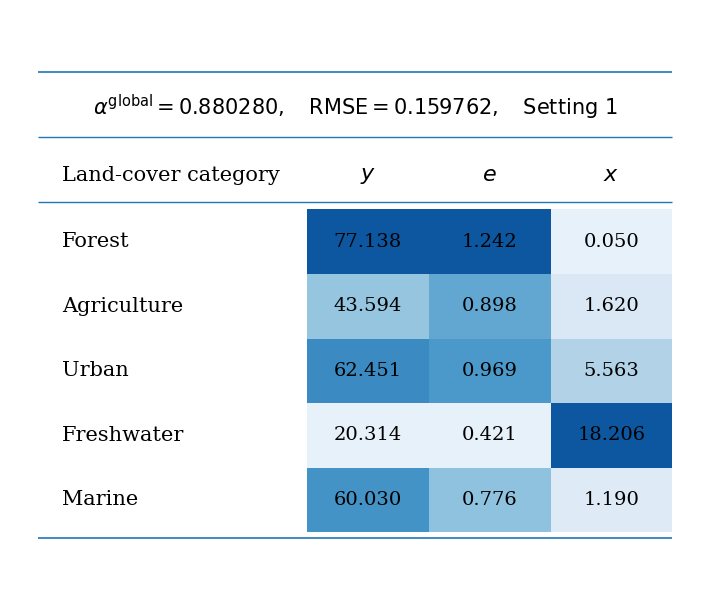

In [ ]:
import matplotlib as mpl


landcover = [
    "Forest",
    "Agriculture",
    "Urban",
    "Freshwater",
    "Marine"
]

values = np.array([
    [77.1376, 1.2424, 0.0500],
    [43.5940, 0.8980, 1.6198],
    [62.4511, 0.9688, 5.5632],
    [20.3136, 0.4210, 18.2064],
    [60.0296, 0.7761, 1.1901]
])

alpha_global = 0.880280
rmse = 0.159762
setting = "Setting 1"


fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Serif font
mpl.rcParams["font.family"] = "serif"

# Layout
left = 0.04
right = 0.96

label_left = 0.075
label_right = 0.43

heat_left = 0.43
heat_right = 0.96

n_cols = 3
cell_w = (heat_right - heat_left) / n_cols


# ax.text(
#     0.5, 0.955,
#     "PSO kudzu",
#     ha="center",
#     va="center",
#     fontsize=15
# )

# top line
ax.hlines(
    0.895,
    left,
    right,
    linewidth=1.2
)


ax.text(
    0.5, 0.835,
    rf"$\alpha^{{\mathrm{{global}}}} = {alpha_global:.6f},"
    rf"\quad \mathrm{{RMSE}} = {rmse:.6f},"
    rf"\quad \mathrm{{{setting.replace(' ', r'\ ')}}}$",
    ha="center",
    va="center",
    fontsize=15
)

ax.hlines(
    0.785,
    left,
    right,
    linewidth=1.0
)


header_y = 0.72

ax.text(
    label_left,
    header_y,
    "Land-cover category",
    ha="left",
    va="center",
    fontsize=15
)

headers = [r"$y$", r"$e$", r"$x$"]

for j, header in enumerate(headers):
    x = heat_left + (j + 0.5) * cell_w
    ax.text(
        x,
        header_y,
        header,
        ha="center",
        va="center",
        fontsize=16
    )

ax.hlines(
    0.675,
    left,
    right,
    linewidth=1.0
)



top = 0.662
bottom = 0.115

n_rows = len(landcover)
cell_h = (top - bottom) / n_rows

cmap = mpl.colormaps["Blues"]

# Normalize
norm_values = np.zeros_like(values, dtype=float)

for j in range(values.shape[1]):
    col = values[:, j]
    min_v = col.min()
    max_v = col.max()

    if max_v > min_v:
        norm_values[:, j] = (col - min_v) / (max_v - min_v)


norm_values = 0.08 + norm_values * 0.77

for i, category in enumerate(landcover):

    y_center = top - (i + 0.5) * cell_h
    y_bottom = top - (i + 1) * cell_h

    # Land-cover name
    ax.text(
        label_left,
        y_center,
        category,
        ha="left",
        va="center",
        fontsize=15
    )

    # Heatmap cells
    for j in range(n_cols):

        x_left = heat_left + j * cell_w

        rect = mpl.patches.Rectangle(
            (x_left, y_bottom),
            cell_w,
            cell_h,
            facecolor=cmap(norm_values[i, j]),
            edgecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            x_left + cell_w / 2,
            y_center,
            f"{values[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=14
        )

# bottom line
ax.hlines(
    bottom - 0.01,
    left,
    right,
    linewidth=1.2
)

plt.tight_layout()
plt.show()

In [ ]:
result_check_pso["Forest_prop"] = Forest_prop
result_check_pso["Agriculture_prop"] = Agriculture_prop
result_check_pso["Urban_prop"] = Urban_prop
result_check_pso["Freshwater_prop"] = Freshwater_prop
result_check_pso["Marine_prop"] = Marine_prop
result_check_pso["y_i"] = (
    Forest_prop * 77.137635
    + Agriculture_prop * 43.593955
    + Urban_prop * 62.451057
    + Freshwater_prop * 20.313617
    + Marine_prop * 60.029642
)
result_check_pso["e_i"] = (
    Forest_prop * 1.242422
    + Agriculture_prop * 0.898008
    + Urban_prop * 0.968765
    + Freshwater_prop * 0.420957
    + Marine_prop * 0.776099
)
result_check_pso["x_i"] = (
    Forest_prop * 0.050033
    + Agriculture_prop * 1.619772
    + Urban_prop * 5.563152
    + Freshwater_prop * 18.206449
    + Marine_prop * 1.190086
)

In [ ]:
result_check_pso[
    [
        "Forest_prop",
        "Agriculture_prop",
        "Urban_prop",
        "Freshwater_prop",
        "Marine_prop",
        "y_i",
        "e_i",
        "x_i",
        "C_i",
        "E_i",
        "p_i_year2"
    ]
].head()

,Forest_prop,Agriculture_prop,Urban_prop,Freshwater_prop,Marine_prop,y_i,e_i,x_i,C_i,E_i,p_i_year2
0,0.966395,0.025320,0.008285,0.0,0.0,76.166626,1.231434,0.135457,6.347947e-33,0.659929,9.619128e-33
1,1.000000,0.000000,0.000000,0.0,0.0,77.137635,1.242422,0.050033,9.154583e-30,0.986742,9.277581e-30
2,0.987013,0.012987,0.000000,0.0,0.0,76.702001,1.237949,0.070419,1.350554e-26,0.895086,1.508854e-26
3,0.940391,0.053840,0.005770,0.0,0.0,75.246914,1.222300,0.166356,2.036900e-23,0.568154,3.585118e-23
4,0.960683,0.039317,0.000000,0.0,0.0,75.818814,1.228881,0.111750,1.365566e-26,0.734533,1.859094e-26


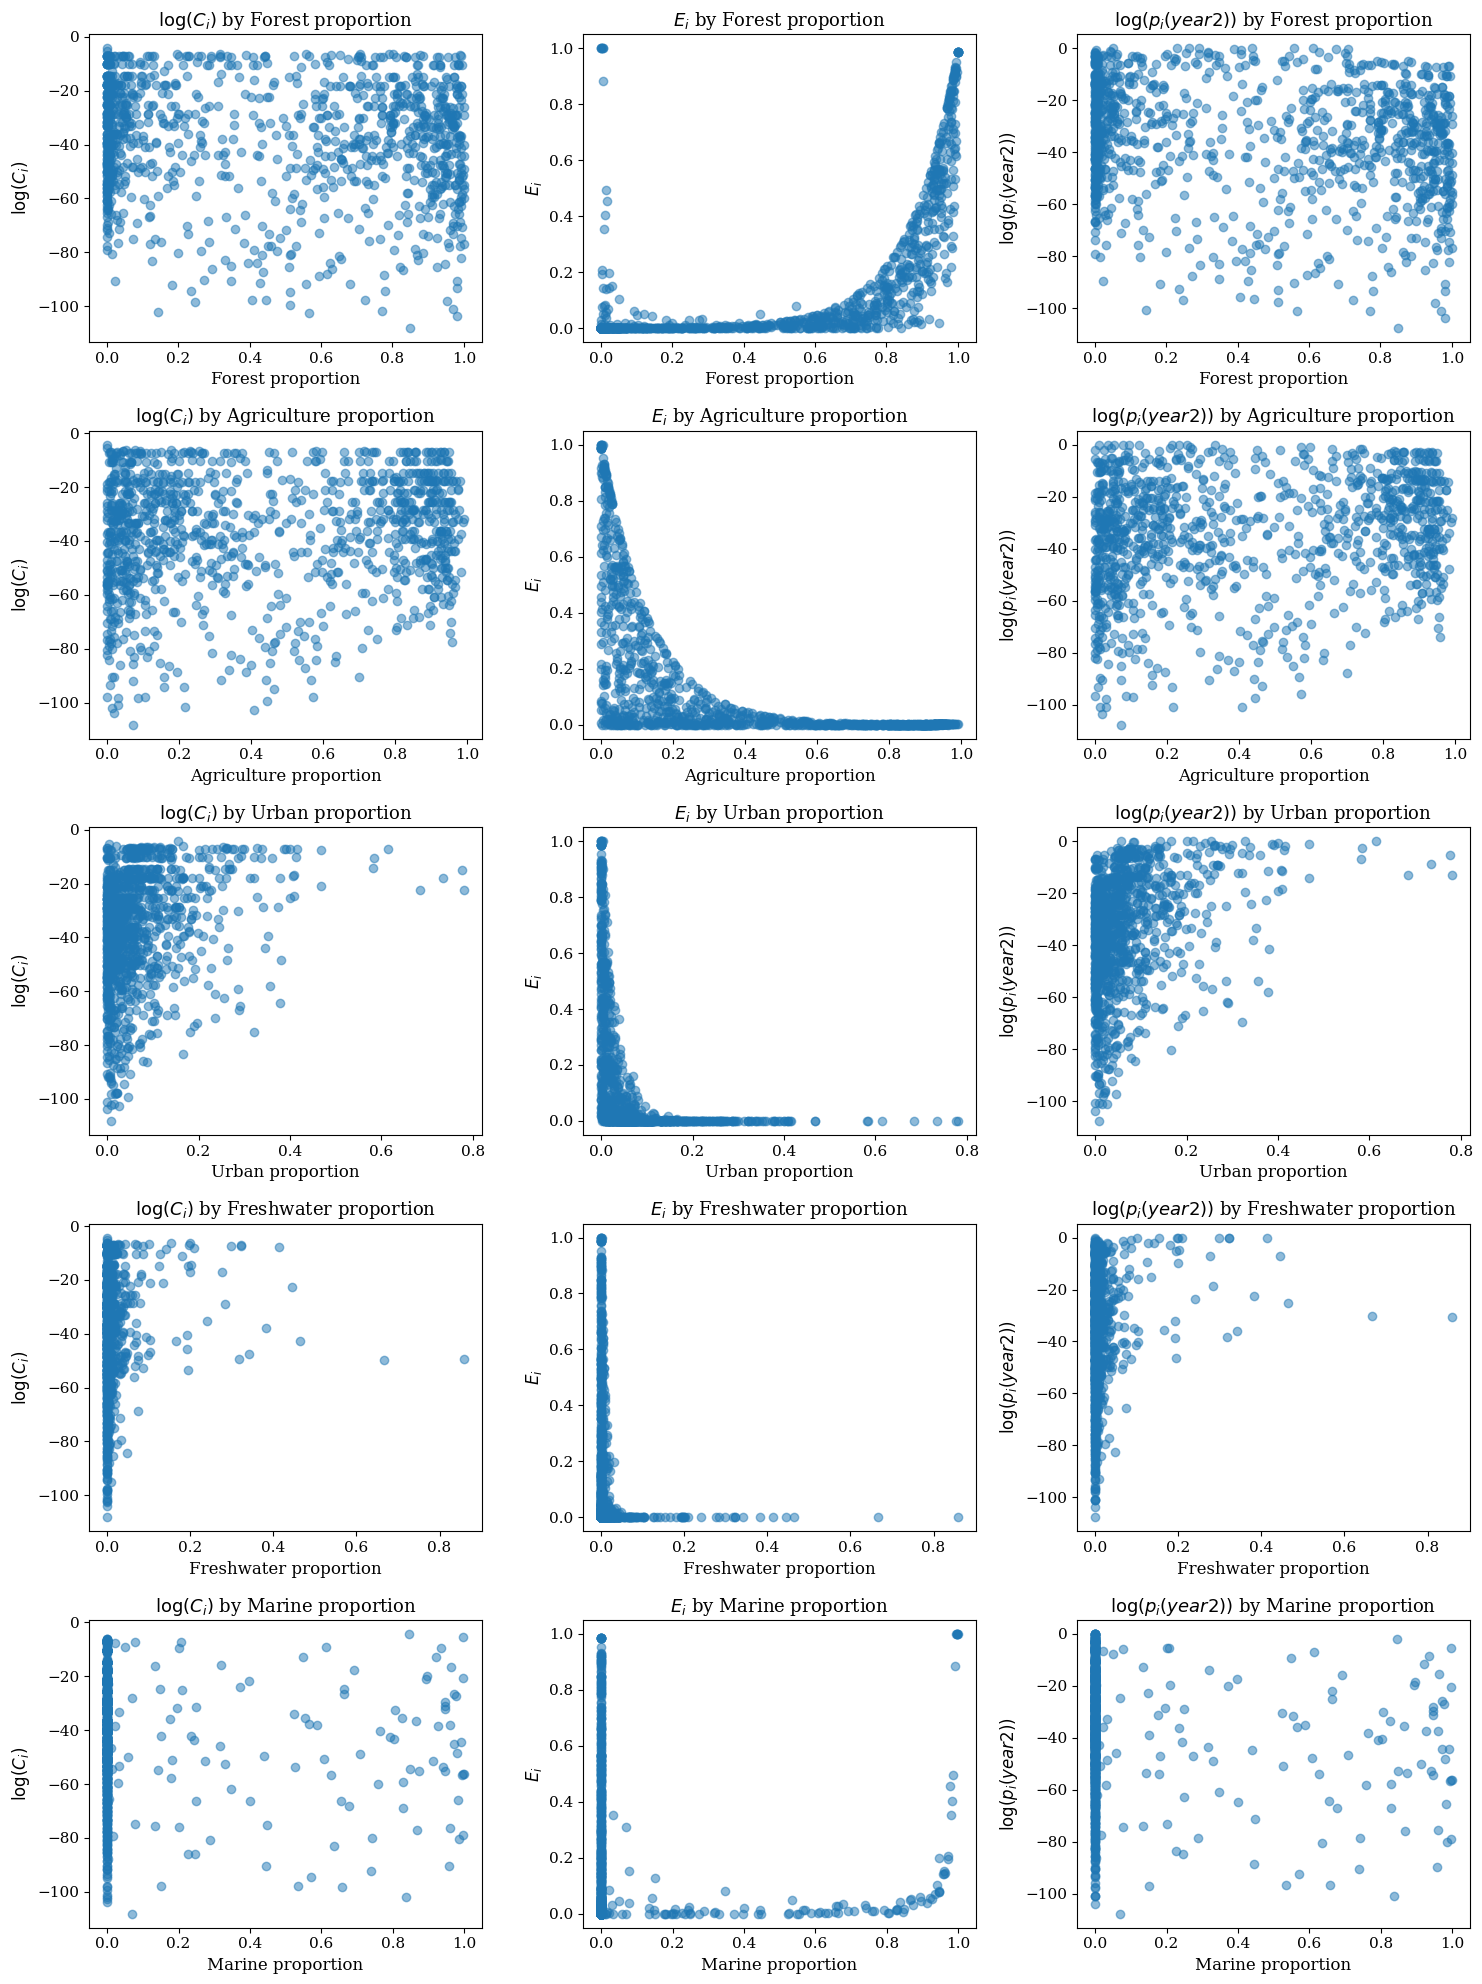

In [ ]:
### plot land-cover proportions and IFM components

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})




landcovers = [
    ("Forest", "Forest_prop"),
    ("Agriculture", "Agriculture_prop"),
    ("Urban", "Urban_prop"),
    ("Freshwater", "Freshwater_prop"),
    ("Marine", "Marine_prop")
]

fig, axes = plt.subplots(5, 3, figsize=(15, 20))

for i, (name, prop_col) in enumerate(landcovers):

    axes[i, 0].scatter(
        result_check_pso[prop_col],
        result_check_pso["log10_C_i"],
        alpha=0.5
    )
    axes[i, 0].set_title(
        rf"$\log(C_i)$ by {name} proportion"
    )
    axes[i, 0].set_xlabel(f"{name} proportion")
    axes[i, 0].set_ylabel(r"$\log(C_i)$")

    axes[i, 1].scatter(
        result_check_pso[prop_col],
        result_check_pso["E_i"],
        alpha=0.5
    )
    axes[i, 1].set_title(
        rf"$E_i$ by {name} proportion"
    )
    axes[i, 1].set_xlabel(f"{name} proportion")
    axes[i, 1].set_ylabel(r"$E_i$")

    axes[i, 2].scatter(
        result_check_pso[prop_col],
        result_check_pso["log10_p_i_year2"],
        alpha=0.5
    )
    axes[i, 2].set_title(
        rf"$\log(p_i(year 2))$ by {name} proportion"
    )
    axes[i, 2].set_xlabel(f"{name} proportion")
    axes[i, 2].set_ylabel(
        r"$\log(p_i(year 2))$"
    )

plt.tight_layout()
plt.show()